In [1029]:
import pandas as pd
import numpy as np
import graphviz
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# import statsmodels.formula.api as smf
# import scipy.stats as stats
import warnings

from statsmodels.formula.api import ols
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
# from sklearn.tree import export_graphviz
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import qqplot, add_constant
# from sklearn.metrics import r2_score
# 로지스틱 회귀
from statsmodels.api import Logit

warnings.filterwarnings('ignore')
import platform
if platform.system() == 'Windows' or 'Linux':
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'  # 윈도우 환경에서는 'Malgun Gothic' 폰트를 사용
else:
    plt.rcParams['font.family'] = 'AppleGothic'  # macOS나 Linux 등 다른 환경에서는 'AppleGothic' 폰트를 사용

matplotlib.rcParams['axes.unicode_minus'] = False

In [1030]:
#데이터 불러오기
df_raw = pd.read_csv(r"/home/piai/바탕화면/bda/2. Big Data 분석 실습파일/SCALE불량.csv", encoding= 'euc-kr')
df_raw

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
0,PLT_1001,03JAN2023:07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조
1,PLT_1002,03JAN2023:07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조
2,PLT_1003,03JAN2023:07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조
3,PLT_1004,03JAN2023:07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조
4,PLT_1005,03JAN2023:07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,...,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PLT_1996,10JAN2023:05:32:25,양품,BV-A,프랑스,C,19,3400,41500,적용,...,2열,1142,55,1151,86,203,CR(제어압연),948,10,4조
996,PLT_1997,10JAN2023:05:39:19,양품,LR-A,영국,C,19,3400,41500,적용,...,2열,1142,55,1151,86,209,CR(제어압연),948,10,4조
997,PLT_1998,10JAN2023:05:52:41,양품,AB/AH32,미국,C,17,3400,43700,적용,...,2열,1169,65,1163,77,227,CR(제어압연),948,10,4조
998,PLT_1999,10JAN2023:06:01:50,양품,NV-A32,영국,C,17,3400,43700,적용,...,2열,1169,65,1163,77,204,CR(제어압연),948,10,4조


# 데이터 분석 

In [1031]:
df_raw.info() #데이터 구조 파악

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   plate_no         1000 non-null   object
 1   rolling_date     1000 non-null   object
 2   scale            1000 non-null   object
 3   spec_long        1000 non-null   object
 4   spec_country     1000 non-null   object
 5   steel_kind       1000 non-null   object
 6   pt_thick         1000 non-null   int64 
 7   pt_width         1000 non-null   int64 
 8   pt_length        1000 non-null   int64 
 9   hsb              1000 non-null   object
 10  fur_no           1000 non-null   object
 11  fur_input_row    1000 non-null   object
 12  fur_heat_temp    1000 non-null   int64 
 13  fur_heat_time    1000 non-null   int64 
 14  fur_soak_temp    1000 non-null   int64 
 15  fur_soak_time    1000 non-null   int64 
 16  fur_total_time   1000 non-null   int64 
 17  rolling_method   1000 non-null   o

# 결측치 조사

In [1032]:
df_raw.isnull().sum() #데이터 결측값 확인 - 없음

plate_no           0
rolling_date       0
scale              0
spec_long          0
spec_country       0
steel_kind         0
pt_thick           0
pt_width           0
pt_length          0
hsb                0
fur_no             0
fur_input_row      0
fur_heat_temp      0
fur_heat_time      0
fur_soak_temp      0
fur_soak_time      0
fur_total_time     0
rolling_method     0
rolling_temp       0
descaling_count    0
work_group         0
dtype: int64

In [1033]:
df_raw['scale'].describe() #목표 변수 scale은 양품이랑 불량이랑 2개로 구성되어 있음

count     1000
unique       2
top         양품
freq       690
Name: scale, dtype: object

In [1034]:
df_raw.describe() 

,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,26.78200,2831.900000,36788.200000,1157.245000,85.972000,1150.928000,71.720000,238.589000,934.637000,8.557000
std,18.13757,494.081478,13912.387116,21.245007,26.346297,17.344384,20.602137,38.194828,96.598015,1.604158
min,12.00000,1800.000000,7900.000000,1103.000000,55.000000,1113.000000,35.000000,165.000000,0.000000,5.000000
25%,15.00000,2500.000000,26650.000000,1140.000000,66.000000,1135.750000,57.750000,210.000000,893.750000,8.000000
50%,19.00000,2800.000000,40400.000000,1159.000000,75.000000,1156.000000,66.000000,230.000000,948.000000,9.000000
75%,34.00000,3100.000000,49100.000000,1173.000000,102.250000,1164.000000,81.000000,263.000000,991.000000,10.000000
max,100.00000,4600.000000,54900.000000,1206.000000,158.000000,1185.000000,145.000000,362.000000,1078.000000,10.000000


In [1035]:
df_raw.describe(include = 'object')

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,hsb,fur_no,fur_input_row,rolling_method,work_group
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,1000,2,66,7,2,2,3,2,2,4
top,PLT_2000,10JAN2023:06:16:27,양품,JS-SM490YB,영국,C,적용,3호기,1열,CR(제어압연),2조
freq,1,1,690,84,256,755,953,342,508,840,292


# BOXPLOT 그리기 (목적: 이상치 탐지 및 처리)

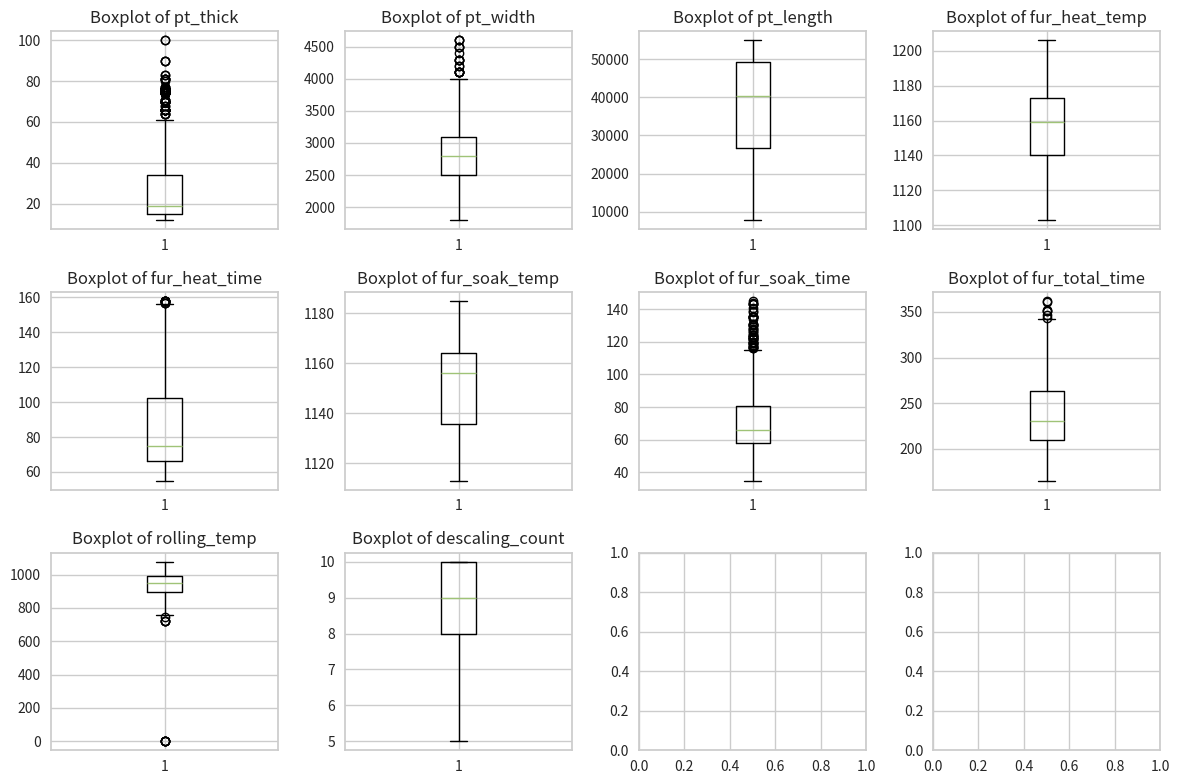

In [1036]:
# 수치형 변수에서 이상치 확인하기 위해 BOX PLOT 그리기
variables = ['pt_thick', 'pt_width', 'pt_length', 'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time',
             'fur_total_time','rolling_temp', 'descaling_count']

# Boxplot
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8))  # 3행 4열의 subplot 생성
axes = axes.flatten()  # 2차원 배열을 1차원으로 펼치기

for i, variable in enumerate(variables):
    axes[i].boxplot(df_raw[variable])
    axes[i].set_title(f"Boxplot of {variable}")

# subplot 간 간격 조정
plt.tight_layout()

# 그래프 출력
plt.show()

In [1037]:
df_raw[df_raw['rolling_temp'] == 0.000000] # rolling_temp이 0인 데이터는 이상치로 판단하여 조사

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
53,PLT_1054,03JAN2023:16:22:29,양품,GL-E36-TM,독일,T,56,3800,11400,적용,...,2열,1132,95,1128,80,244,TMCP(온도제어),0,6,1조
221,PLT_1222,04JAN2023:19:44:09,양품,JS-SM490YB,일본,C,16,2200,43600,적용,...,2열,1163,57,1166,67,228,CR(제어압연),0,10,2조
222,PLT_1223,04JAN2023:19:56:39,양품,JS-SM490YB,일본,C,16,2200,43600,적용,...,1열,1169,64,1164,61,188,CR(제어압연),0,10,2조
598,PLT_1599,07JAN2023:11:40:51,양품,PILAC-BT33,한국,T,81,2100,12900,적용,...,1열,1133,89,1122,59,229,CR(제어압연),0,6,3조
599,PLT_1600,07JAN2023:11:52:00,양품,PILAC-BT33,한국,T,81,2100,13200,적용,...,2열,1130,92,1124,61,210,CR(제어압연),0,6,3조
600,PLT_1601,07JAN2023:11:59:10,양품,NV-D32-TM,영국,T,40,2500,23600,적용,...,1열,1119,109,1117,76,260,TMCP(온도제어),0,6,3조


In [1038]:
#이상치 처리
#이상치 6개 모두 양품이 나옴. 따라서 평균값으로 대체해도 무방하다고 판단하여 평균값으로 대체
#대체 방법은 같은 spec 중에서 평균값으로 대체한다. spec은 pt_thick, pt_width, pt_length의 조합으로 정의한다. 
#후에 Spec과 관련된 나라나 이런걸 조사해도 될 것 같다. 파생변수로!

In [1039]:
df_raw[df_raw['spec_long'] == 'GL-E36-TM'] #16개 중 1개가 불량. 따라서 나머지 15개의 평균값으로 대체

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
26,PLT_1027,03JAN2023:11:37:34,양품,GL-E36-TM,독일,T,44,2000,27500,적용,...,1열,1114,64,1120,82,240,TMCP(온도제어),836,6,1조
27,PLT_1028,03JAN2023:11:44:48,양품,GL-E36-TM,독일,T,44,2000,27500,적용,...,1열,1113,124,1120,82,276,TMCP(온도제어),832,6,1조
28,PLT_1029,03JAN2023:11:59:39,양품,GL-E36-TM,독일,T,48,2100,24500,적용,...,2열,1118,71,1124,86,216,TMCP(온도제어),832,6,1조
29,PLT_1030,03JAN2023:12:13:55,양품,GL-E36-TM,독일,T,48,2100,24500,적용,...,1열,1117,69,1120,88,240,TMCP(온도제어),832,6,1조
30,PLT_1031,03JAN2023:12:20:57,양품,GL-E36-TM,독일,T,48,2000,25600,적용,...,2열,1108,62,1117,97,219,TMCP(온도제어),841,6,1조
45,PLT_1046,03JAN2023:14:51:41,양품,GL-E36-TM,독일,T,44,2500,15700,적용,...,2열,1133,75,1127,91,247,TMCP(온도제어),837,6,1조
52,PLT_1053,03JAN2023:16:11:06,양품,GL-E36-TM,독일,T,56,3800,11400,적용,...,1열,1126,62,1125,106,256,TMCP(온도제어),863,6,1조
53,PLT_1054,03JAN2023:16:22:29,양품,GL-E36-TM,독일,T,56,3800,11400,적용,...,2열,1132,95,1128,80,244,TMCP(온도제어),0,6,1조
98,PLT_1099,03JAN2023:23:40:58,양품,GL-E36-TM,독일,T,76,2500,14100,적용,...,1열,1126,103,1125,61,251,TMCP(온도제어),843,6,2조
103,PLT_1104,04JAN2023:00:28:55,양품,GL-E36-TM,독일,T,76,2500,14100,적용,...,1열,1133,94,1125,76,269,TMCP(온도제어),859,6,2조


In [1040]:
mean_temp = df_raw[(df_raw['spec_long'] == 'GL-E36-TM') &
                   (df_raw['scale'] == '양품') &
                   (df_raw['rolling_temp'] != 0)]['rolling_temp'].mean()


df_raw.loc[(df_raw['spec_long'] == 'GL-E36-TM') &
           (df_raw['rolling_temp'] == 0),
           'rolling_temp'] = mean_temp

In [1041]:
df_raw[df_raw['rolling_temp'] == 0.000000] #(GL -E36-TM spec의 하나 제거)

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
221,PLT_1222,04JAN2023:19:44:09,양품,JS-SM490YB,일본,C,16,2200,43600,적용,...,2열,1163,57,1166,67,228,CR(제어압연),0.0,10,2조
222,PLT_1223,04JAN2023:19:56:39,양품,JS-SM490YB,일본,C,16,2200,43600,적용,...,1열,1169,64,1164,61,188,CR(제어압연),0.0,10,2조
598,PLT_1599,07JAN2023:11:40:51,양품,PILAC-BT33,한국,T,81,2100,12900,적용,...,1열,1133,89,1122,59,229,CR(제어압연),0.0,6,3조
599,PLT_1600,07JAN2023:11:52:00,양품,PILAC-BT33,한국,T,81,2100,13200,적용,...,2열,1130,92,1124,61,210,CR(제어압연),0.0,6,3조
600,PLT_1601,07JAN2023:11:59:10,양품,NV-D32-TM,영국,T,40,2500,23600,적용,...,1열,1119,109,1117,76,260,TMCP(온도제어),0.0,6,3조


In [1042]:
mean_temp = df_raw[(df_raw['spec_long'] == 'JS-SM490YB') &
                   (df_raw['scale'] == '양품') &
                   (df_raw['rolling_temp'] != 0)]['rolling_temp'].mean()


df_raw.loc[(df_raw['spec_long'] == 'JS-SM490YB') &
           (df_raw['rolling_temp'] == 0),
           'rolling_temp'] = mean_temp

In [1043]:
df_raw[df_raw['rolling_temp'] == 0.000000] #2개 제거

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
598,PLT_1599,07JAN2023:11:40:51,양품,PILAC-BT33,한국,T,81,2100,12900,적용,...,1열,1133,89,1122,59,229,CR(제어압연),0.0,6,3조
599,PLT_1600,07JAN2023:11:52:00,양품,PILAC-BT33,한국,T,81,2100,13200,적용,...,2열,1130,92,1124,61,210,CR(제어압연),0.0,6,3조
600,PLT_1601,07JAN2023:11:59:10,양품,NV-D32-TM,영국,T,40,2500,23600,적용,...,1열,1119,109,1117,76,260,TMCP(온도제어),0.0,6,3조


In [1044]:
mean_temp = df_raw[(df_raw['spec_long'] == 'PILAC-BT33') &
                   (df_raw['scale'] == '양품') &
                   (df_raw['rolling_temp'] != 0)]['rolling_temp'].mean()


df_raw.loc[(df_raw['spec_long'] == 'PILAC-BT33') &
           (df_raw['rolling_temp'] == 0),
           'rolling_temp'] = mean_temp

In [1045]:
df_raw[df_raw['rolling_temp'] == 0.000000] #2개 제거

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group
600,PLT_1601,07JAN2023:11:59:10,양품,NV-D32-TM,영국,T,40,2500,23600,적용,...,1열,1119,109,1117,76,260,TMCP(온도제어),0.0,6,3조


In [1046]:
mean_temp = df_raw[(df_raw['spec_long'] == 'NV-D32-TM') &
                   (df_raw['scale'] == '양품') &
                   (df_raw['rolling_temp'] != 0)]['rolling_temp'].mean()


df_raw.loc[(df_raw['spec_long'] == 'NV-D32-TM') &
           (df_raw['rolling_temp'] == 0),
           'rolling_temp'] = mean_temp

In [1047]:
df_raw[df_raw['rolling_temp'] == 0.000000] #rolling_temp가 0인 데이터 모두 제거 완료

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group


In [1048]:
df_raw['rolling_temp'].describe() #검증

count    1000.000000
mean      940.060681
std        63.810004
min       723.000000
25%       894.000000
50%       948.000000
75%       991.000000
max      1078.000000
Name: rolling_temp, dtype: float64

# 데이터 정제

In [1049]:
#Plate_no 제거
df_raw.drop(["plate_no"], axis = 1, inplace = True)
df_raw.columns

Index(['rolling_date', 'scale', 'spec_long', 'spec_country', 'steel_kind',
       'pt_thick', 'pt_width', 'pt_length', 'hsb', 'fur_no', 'fur_input_row',
       'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time',
       'fur_total_time', 'rolling_method', 'rolling_temp', 'descaling_count',
       'work_group'],
      dtype='object')

In [1050]:
df_raw['scale'] = np.where(df_raw['scale'] == "불량", 1, 0)
df_raw['scale'].value_counts() #양품이 690 불량이 310

scale
0    690
1    310
Name: count, dtype: int64

In [1051]:
df_raw_x = df_raw.drop(["scale"], axis = 1, inplace = False) # 설명 변수 
df_raw_y = df_raw["scale"] # 목표 변수

# 범주형/연속형 데이터 분석

In [1052]:
df_object = df_raw_x.select_dtypes(include = 'object')
obj_cols = df_object.columns
obj_cols

Index(['rolling_date', 'spec_long', 'spec_country', 'steel_kind', 'hsb',
       'fur_no', 'fur_input_row', 'rolling_method', 'work_group'],
      dtype='object')

In [1053]:
for col in obj_cols:
    _n = len(df_raw[col].value_counts()) 
    print(col, ":", str(_n))
#이대로 더미변수를 만들면 너무 난잡해지는 Dataset 따라서 군집분석을 진행할 것이다. 

rolling_date : 1000
spec_long : 66
spec_country : 7
steel_kind : 2
hsb : 2
fur_no : 3
fur_input_row : 2
rolling_method : 2
work_group : 4


In [1054]:
df_numeric = df_raw_x.select_dtypes(exclude = 'object')
num_cols = df_numeric.columns
num_cols

#scaling은 흠.. 아직 변수들에 대한 이해/지식이 부족하기에, 오히려 헷갈릴 거 같다고 판단됨
#따라서 스케일링은 일단 진행하지 않는다.
# 하지만 이따가 VIF 값이 너무 크게 나와서 SCALING진행 

Index(['pt_thick', 'pt_width', 'pt_length', 'fur_heat_temp', 'fur_heat_time',
       'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_temp',
       'descaling_count'],
      dtype='object')

## 범주형 변수, scale 카이제곱검정

In [1055]:
from scipy.stats import chi2_contingency
import pandas as pd

cat_cols = ['spec_long', 'spec_country',
       'steel_kind', 'hsb', 'fur_no', 'fur_input_row', 'rolling_method',
       'work_group']  # 범주형 변수들

result = []

for col in cat_cols:
    table = pd.crosstab(df_raw[col], df_raw['scale'])
    chi2, p, dof, expected = chi2_contingency(table)
    
    result.append({
        '변수': col,
        'p_value': p.round(4),
        '결과': '○' if p < 0.05 else '×'
    })

result_df = pd.DataFrame(result)
print(result_df)

               변수  p_value 결과
0       spec_long   0.0000  ○
1    spec_country   0.0000  ○
2      steel_kind   0.0000  ○
3             hsb   0.0000  ○
4          fur_no   0.2442  ×
5   fur_input_row   0.3370  ×
6  rolling_method   0.0000  ○
7      work_group   0.0031  ○


fur_no, fur_input_row의 p-value가 0.05보다 크다.

따라서 fur_no, fur_input_row 변수는 유의하지 않다.

## 연속형 변수, scale t검정

In [1056]:
df_raw['pt_dim']=df_raw['pt_width']*df_raw['pt_thick']


In [1057]:
# t/f 검정
from scipy.stats import ttest_ind
num_cols = [ 'fur_heat_temp', 'pt_dim',            
            'fur_heat_time', 'fur_soak_temp', 'fur_soak_time',             
            'fur_total_time', 'rolling_temp', 'descaling_count']
result = []
for col in num_cols:        
    g0 = df_raw[df_raw['scale']==0][col]    
    g1 = df_raw[df_raw['scale']==1][col]        
    t, p = ttest_ind(g0, g1)        
    result.append({'변수': col, 'p_value': p.round(4),'결과': '○' if p < 0.05 else '×'})
    
result_df = pd.DataFrame(result)
print(result_df)

                변수  p_value 결과
0    fur_heat_temp   0.0000  ○
1           pt_dim   0.0000  ○
2    fur_heat_time   0.2577  ×
3    fur_soak_temp   0.0000  ○
4    fur_soak_time   0.0000  ○
5   fur_total_time   0.0001  ○
6     rolling_temp   0.0000  ○
7  descaling_count   0.2062  ×


fur_heat_time, descaling_count의 p-value가 0.05보다 크다.

따라서 fur_heat_time, descaling_count 변수는 유의하지 않다.

# EDA 

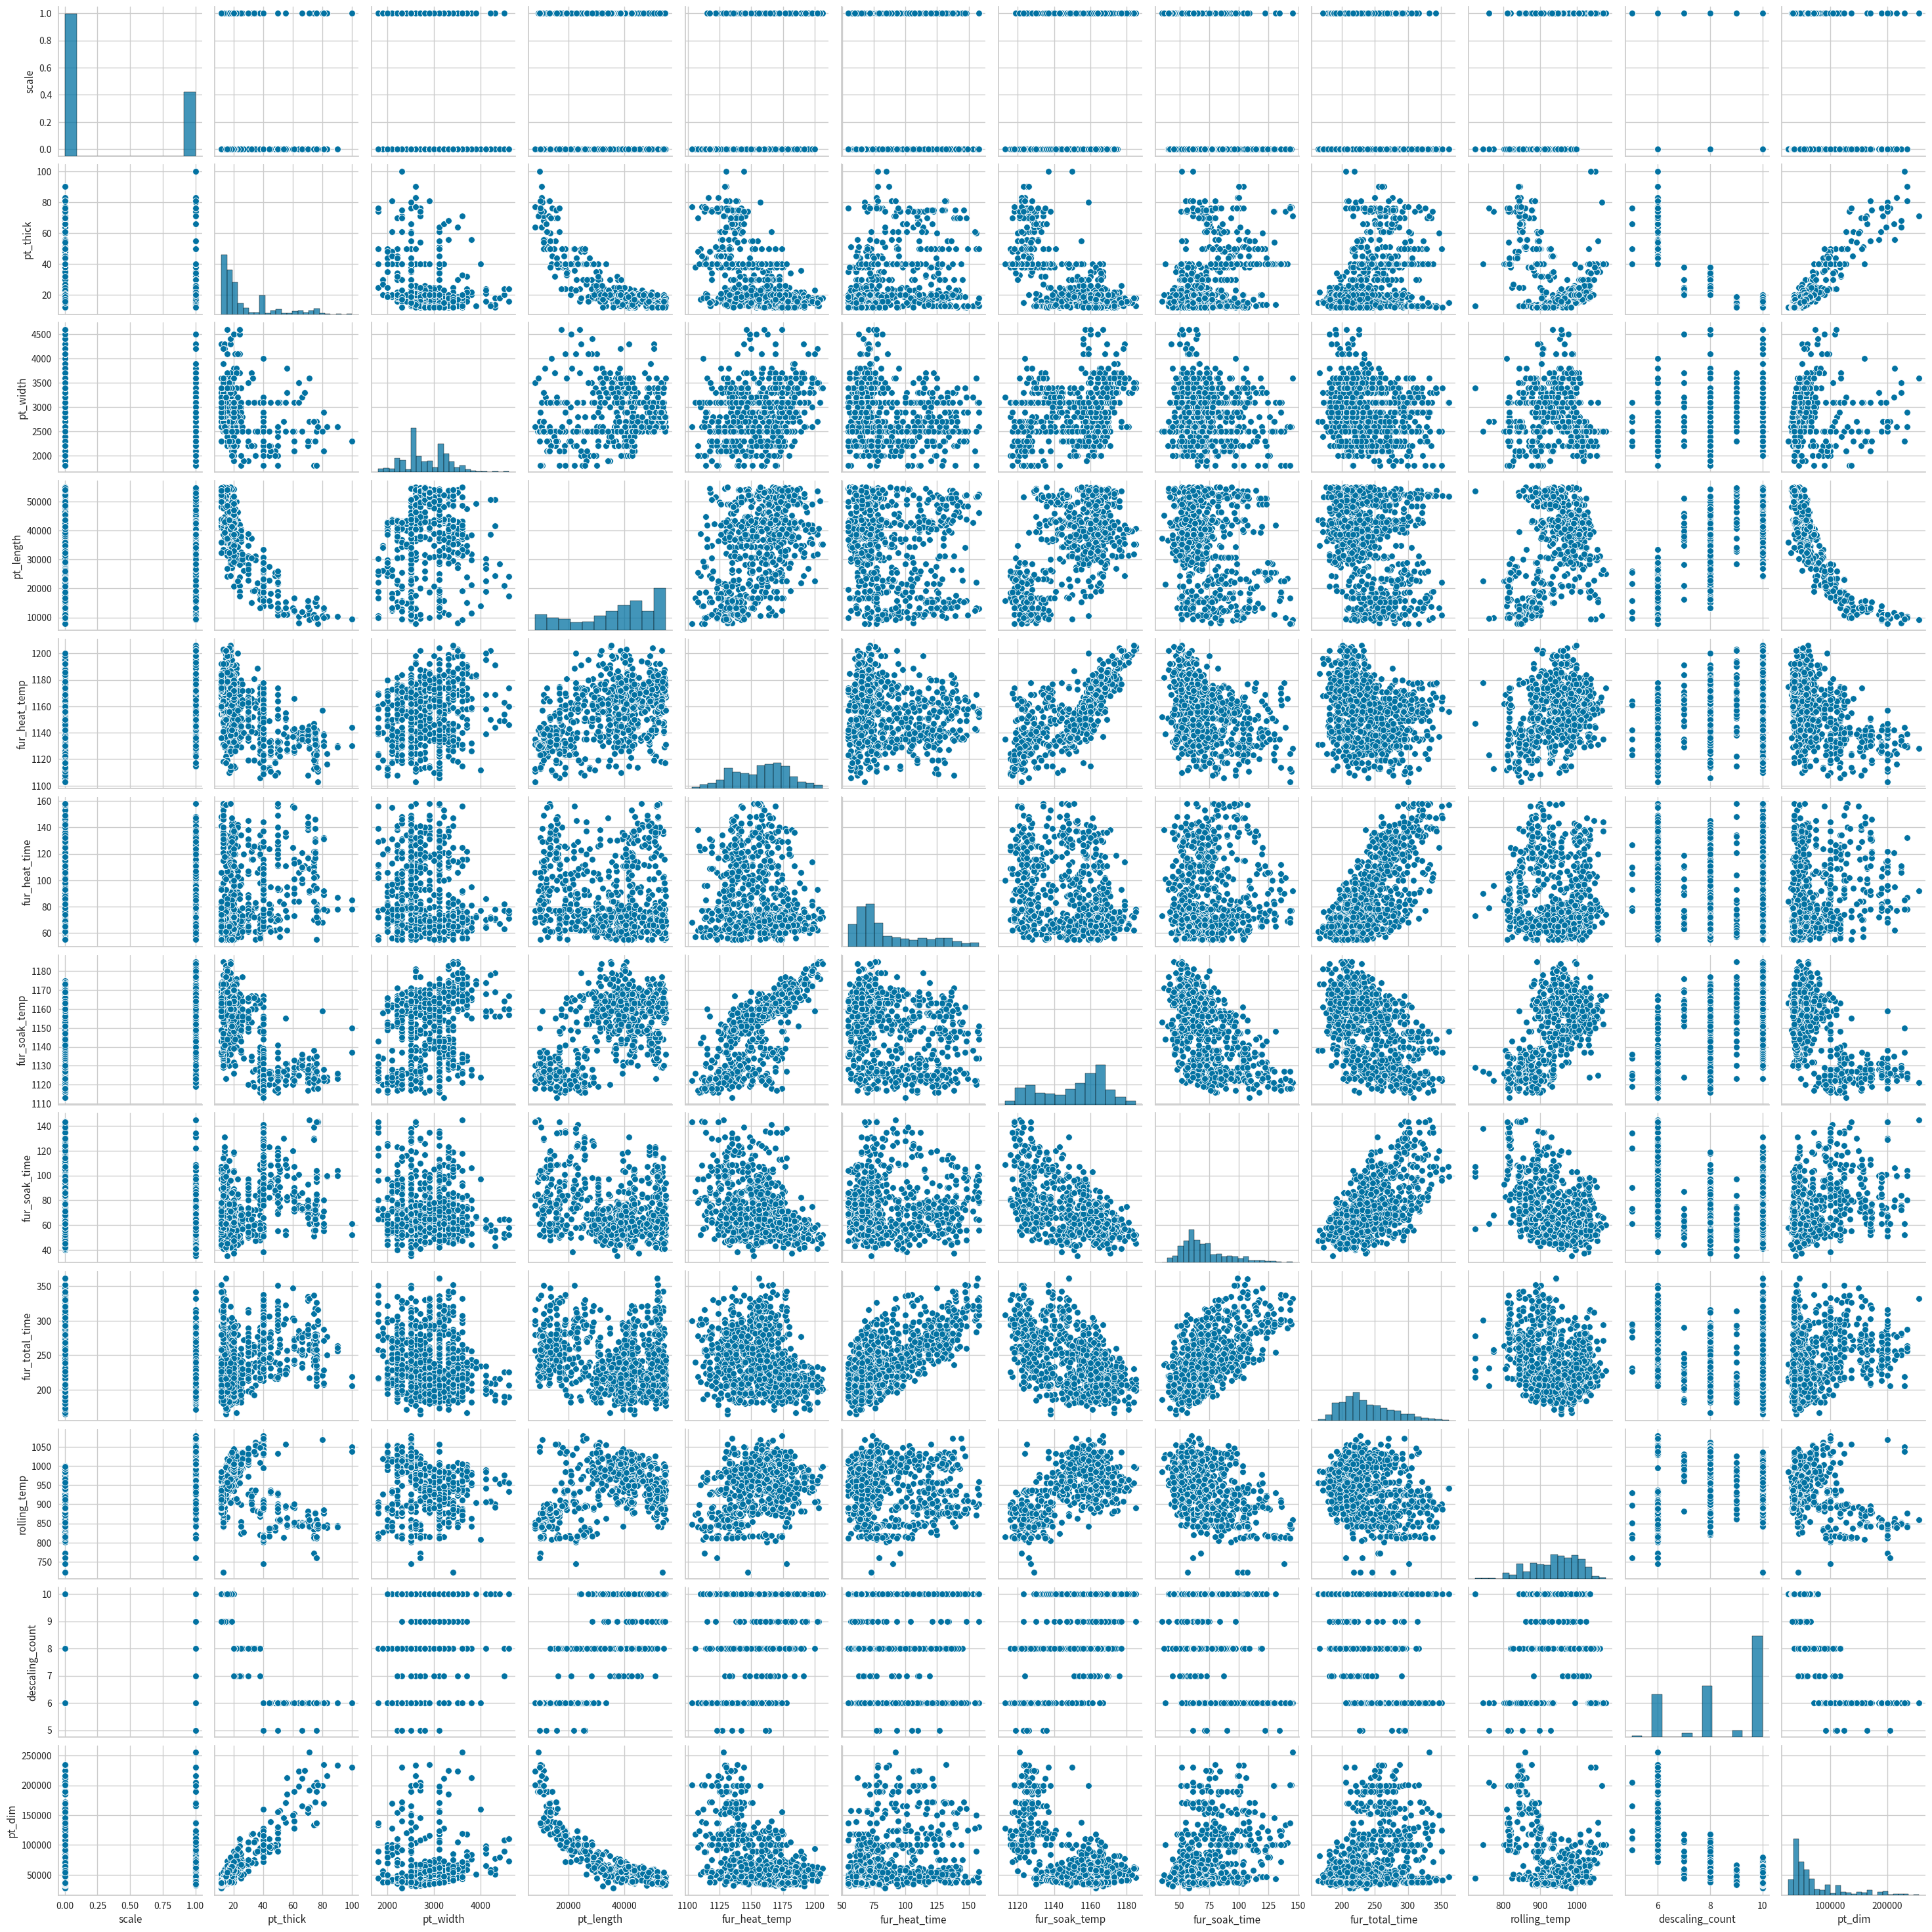

In [1058]:
# 변수가 너무 많아서 변수간의 상관관계를 파악하고 다중공선성 확인하는 과정
sns.pairplot(df_raw)

In [1059]:
#일단 범주형 뺴고 연속형 변수로만 상관관계를 분석한다. 
df_raw.select_dtypes(include='number').corr().round(3)

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count,pt_dim
scale,1.000,-0.098,-0.190,0.052,0.222,-0.036,0.328,-0.220,-0.128,0.512,-0.040,-0.141
pt_thick,-0.098,1.000,-0.320,-0.867,-0.525,0.207,-0.666,0.357,0.338,-0.454,-0.845,0.953
pt_width,-0.190,-0.320,1.000,0.148,0.201,-0.101,0.217,-0.097,-0.133,-0.154,0.350,-0.063
pt_length,0.052,-0.867,0.148,1.000,0.471,-0.138,0.603,-0.334,-0.276,0.370,0.818,-0.881
fur_heat_temp,0.222,-0.525,0.201,0.471,1.000,-0.164,0.787,-0.373,-0.314,0.345,0.488,-0.503
fur_heat_time,-0.036,0.207,-0.101,-0.138,-0.164,1.000,-0.349,0.115,0.736,-0.134,-0.167,0.178
fur_soak_temp,0.328,-0.666,0.217,0.603,0.787,-0.349,1.000,-0.597,-0.561,0.630,0.628,-0.640
fur_soak_time,-0.220,0.357,-0.097,-0.334,-0.373,0.115,-0.597,1.000,0.633,-0.485,-0.399,0.348
fur_total_time,-0.128,0.338,-0.133,-0.276,-0.314,0.736,-0.561,0.633,1.000,-0.344,-0.339,0.311
rolling_temp,0.512,-0.454,-0.154,0.370,0.345,-0.134,0.630,-0.485,-0.344,1.000,0.318,-0.499


In [1060]:
#다중공산성 의심.. 히트맵을 통해서 상관관계가 높은 변수들을 찾음. 
import numpy as np

corr = df_numeric.corr()

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i,j]) > 0.6:
            print(corr.columns[i], "-", corr.columns[j], ":", corr.iloc[i,j])

pt_length - pt_thick : -0.8671251949475853
fur_soak_temp - pt_thick : -0.6659637810058185
fur_soak_temp - pt_length : 0.6033031703452889
fur_soak_temp - fur_heat_temp : 0.7872027986995761
fur_total_time - fur_heat_time : 0.736068642703049
fur_total_time - fur_soak_time : 0.6329954631523077
rolling_temp - fur_soak_temp : 0.6300452807073322
descaling_count - pt_thick : -0.8453244850402628
descaling_count - pt_length : 0.8184831357902199
descaling_count - fur_soak_temp : 0.6278433301622628


In [1061]:
df_raw.head()

,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,...,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,pt_dim
0,03JAN2023:07:07:53,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,...,1144,116,1133,59,259,TMCP(온도제어),934.0,8,1조,118400
1,03JAN2023:07:21:22,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,...,1144,122,1135,53,238,TMCP(온도제어),937.0,8,1조,118400
2,03JAN2023:07:31:15,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,...,1129,116,1121,55,258,TMCP(온도제어),889.0,8,1조,118800
3,03JAN2023:07:41:01,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,...,1152,125,1127,68,266,TMCP(온도제어),885.0,8,1조,118800
4,03JAN2023:07:52:40,0,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,...,1140,134,1128,48,246,TMCP(온도제어),873.0,8,1조,117800


# 군집분석

In [1062]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib
import matplotlib.pyplot as plt

# Scale 변환:평균,표준편차 기준
from sklearn.preprocessing import StandardScaler
# linkage: 계층형 군집분석, dendrogram: 계층구조 나무, cluster: linkage로부터 얻은 값으로 군집 생성
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# 군집 방법 : AgglomerativeClustering(계층형), KMeans(k-평균), DBSCAN
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

# 실루엣(Silhouette) 계수 산출
from sklearn.metrics import silhouette_samples, silhouette_score
# 실루엣 계수 산출 및 시각화 라이브러리 (pip install yellowbrick 실행)
from yellowbrick.cluster import SilhouetteVisualizer

In [1063]:
df_spec = df_raw.drop(['rolling_date', 'work_group', 'scale', 'spec_country'], axis=1)

In [1064]:
df_spec.columns

Index(['spec_long', 'steel_kind', 'pt_thick', 'pt_width', 'pt_length', 'hsb',
       'fur_no', 'fur_input_row', 'fur_heat_temp', 'fur_heat_time',
       'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_method',
       'rolling_temp', 'descaling_count', 'pt_dim'],
      dtype='object')

In [1065]:
dummy_cols = ['rolling_method', 'fur_input_row', 'fur_no', 'hsb', 'steel_kind']
df_dummy = pd.get_dummies(df_spec, columns=dummy_cols, drop_first=False, dtype=int)

df_dummy.head()

,spec_long,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,...,rolling_method_TMCP(온도제어),fur_input_row_1열,fur_input_row_2열,fur_no_1호기,fur_no_2호기,fur_no_3호기,hsb_미적용,hsb_적용,steel_kind_C,steel_kind_T
0,AB/EH32-TM,32,3700,15100,1144,116,1133,59,259,934.0,...,1,1,0,1,0,0,0,1,0,1
1,AB/EH32-TM,32,3700,15100,1144,122,1135,53,238,937.0,...,1,0,1,1,0,0,0,1,0,1
2,NV-E36-TM,33,3600,19200,1129,116,1121,55,258,889.0,...,1,1,0,0,1,0,0,1,0,1
3,NV-E36-TM,33,3600,19200,1152,125,1127,68,266,885.0,...,1,0,1,0,1,0,0,1,0,1
4,BV-EH36-TM,38,3100,13300,1140,134,1128,48,246,873.0,...,1,1,0,0,0,1,0,1,0,1


In [1066]:
print(df_dummy.dtypes.value_counts())

int64      21
object      1
float64     1
Name: count, dtype: int64


In [1067]:
df_spec = df_dummy.groupby(['spec_long']).mean(numeric_only=True)
df_spec

,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count,...,rolling_method_TMCP(온도제어),fur_input_row_1열,fur_input_row_2열,fur_no_1호기,fur_no_2호기,fur_no_3호기,hsb_미적용,hsb_적용,steel_kind_C,steel_kind_T
spec_long,,,,,,,,,,,,,,,,,,,,,
A131-DH36TM,71.000000,3600.000000,9200.000000,1128.000000,92.000000,1121.000000,145.000000,332.000000,859.000000,6.000000,...,0.0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.0,1.0
A283-C,23.500000,2600.000000,32333.333333,1166.666667,69.500000,1161.333333,68.166667,222.166667,1014.000000,8.500000,...,0.0,0.500000,0.500000,0.333333,0.500000,0.166667,0.000000,1.000000,1.0,0.0
A516-60,16.000000,3333.333333,45100.000000,1177.000000,72.000000,1171.000000,68.666667,236.000000,938.000000,9.333333,...,0.0,0.333333,0.666667,0.666667,0.333333,0.000000,0.333333,0.666667,1.0,0.0
A709-36,26.000000,2800.000000,28900.000000,1150.000000,63.000000,1154.000000,59.000000,197.000000,993.000000,8.000000,...,0.0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.0,0.0
AB/A,16.431373,3017.647059,45741.176471,1161.960784,92.705882,1155.176471,67.313725,238.960784,947.039216,9.529412,...,0.0,0.470588,0.529412,0.294118,0.294118,0.411765,0.058824,0.941176,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NV-E32-TM,13.500000,2500.000000,54500.000000,1149.000000,86.000000,1146.500000,73.500000,245.500000,890.500000,10.000000,...,1.0,0.500000,0.500000,0.500000,0.000000,0.500000,0.000000,1.000000,0.0,1.0
NV-E36-TM,52.800000,3160.000000,15100.000000,1135.400000,108.600000,1127.400000,69.800000,251.800000,862.800000,6.800000,...,1.0,0.400000,0.600000,0.400000,0.600000,0.000000,0.000000,1.000000,0.0,1.0
PILAC-BT33,63.675000,2322.500000,14982.500000,1143.550000,125.475000,1123.850000,84.675000,288.000000,885.609722,6.000000,...,0.0,0.475000,0.525000,0.400000,0.400000,0.200000,0.050000,0.950000,0.0,1.0


In [1068]:
scaler = StandardScaler()
df_spec_scaled = scaler.fit_transform(df_spec)

In [1069]:
df_spec_y = df_spec_scaled[:, 0]
df_spec_x = df_spec_scaled[:,1::]

In [1070]:
# 연결: ward, 거리 계산: Euclidean: ward~Euclidean
Z_ward = linkage(df_spec_x, method = "ward", metric = "euclidean")
# 연결: average, 거리 계산: Euclidean
Z_average = linkage(df_spec_x, method = "average", metric = "euclidean")

Text(0, 0.5, 'Distance')

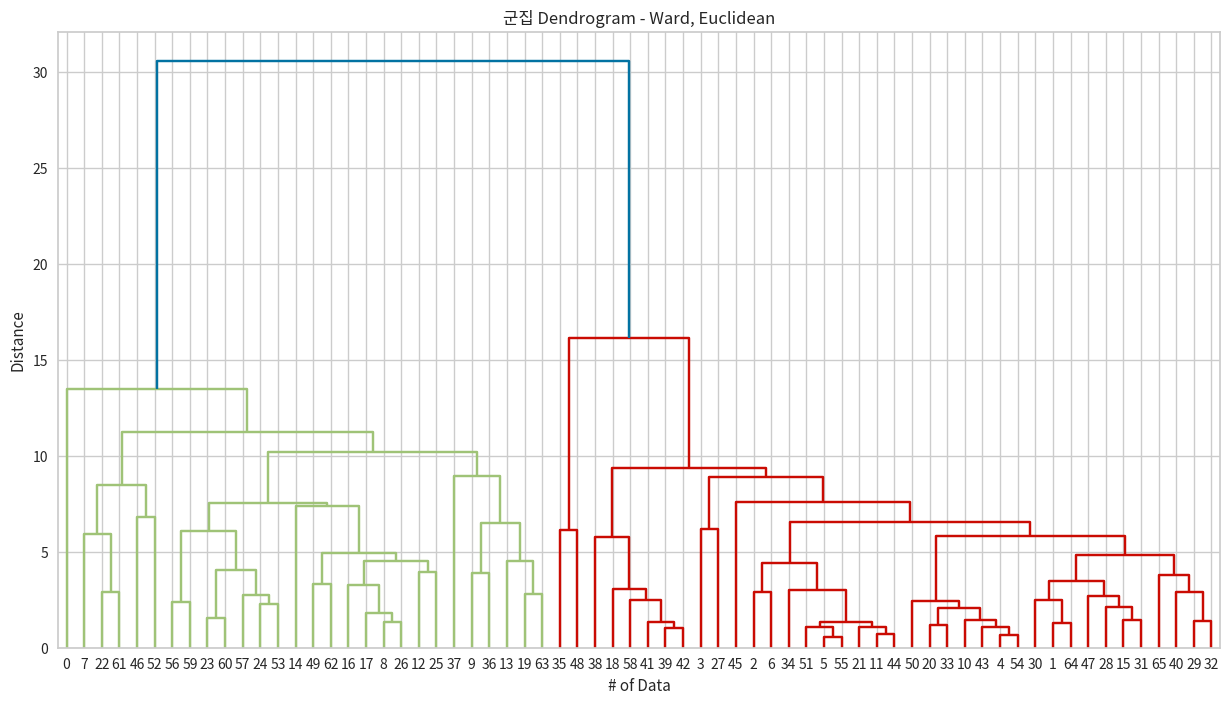

In [1071]:
plt.figure(figsize=(15,8))
ax = plt.subplot(111) 
# DataFrame 변경:Z_ward, Z_average, Z_Minkowski
dendrogram(Z_ward, leaf_font_size=10, leaf_rotation=0, orientation= "top")
plt.title("군집 Dendrogram - Ward, Euclidean")
plt.xlabel("# of Data")
plt.ylabel("Distance")

In [1072]:
from scipy.cluster.hierarchy import fcluster

df_spec['cluster_H'] = fcluster(Z =Z_ward, t=12, criterion='distance')
df_spec['cluster_H'].unique()

array([2, 4, 1, 3], dtype=int32)

In [1073]:
df_spec.reset_index(drop = False, inplace = True)
df_cluster_spec = df_spec[['spec_long', 'cluster_H']]

In [1074]:
spec_cluster = pd.merge(df_raw, df_cluster_spec, how='left', on = 'spec_long')
spec_cluster

,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,...,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,pt_dim,cluster_H
0,03JAN2023:07:07:53,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,...,116,1133,59,259,TMCP(온도제어),934.0,8,1조,118400,1
1,03JAN2023:07:21:22,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,...,122,1135,53,238,TMCP(온도제어),937.0,8,1조,118400,1
2,03JAN2023:07:31:15,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,...,116,1121,55,258,TMCP(온도제어),889.0,8,1조,118800,1
3,03JAN2023:07:41:01,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,...,125,1127,68,266,TMCP(온도제어),885.0,8,1조,118800,1
4,03JAN2023:07:52:40,0,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,...,134,1128,48,246,TMCP(온도제어),873.0,8,1조,117800,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10JAN2023:05:32:25,0,BV-A,프랑스,C,19,3400,41500,적용,1호기,...,55,1151,86,203,CR(제어압연),948.0,10,4조,64600,4
996,10JAN2023:05:39:19,0,LR-A,영국,C,19,3400,41500,적용,1호기,...,55,1151,86,209,CR(제어압연),948.0,10,4조,64600,4
997,10JAN2023:05:52:41,0,AB/AH32,미국,C,17,3400,43700,적용,2호기,...,65,1163,77,227,CR(제어압연),948.0,10,4조,57800,4
998,10JAN2023:06:01:50,0,NV-A32,영국,C,17,3400,43700,적용,2호기,...,65,1163,77,204,CR(제어압연),948.0,10,4조,57800,4


In [1075]:

spec_cluster.drop(["spec_long"], axis = 1, inplace = True)
spec_cluster

,rolling_date,scale,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,...,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,pt_dim,cluster_H
0,03JAN2023:07:07:53,0,미국,T,32,3700,15100,적용,1호기,1열,...,116,1133,59,259,TMCP(온도제어),934.0,8,1조,118400,1
1,03JAN2023:07:21:22,0,미국,T,32,3700,15100,적용,1호기,2열,...,122,1135,53,238,TMCP(온도제어),937.0,8,1조,118400,1
2,03JAN2023:07:31:15,0,영국,T,33,3600,19200,적용,2호기,1열,...,116,1121,55,258,TMCP(온도제어),889.0,8,1조,118800,1
3,03JAN2023:07:41:01,0,영국,T,33,3600,19200,적용,2호기,2열,...,125,1127,68,266,TMCP(온도제어),885.0,8,1조,118800,1
4,03JAN2023:07:52:40,0,프랑스,T,38,3100,13300,적용,3호기,1열,...,134,1128,48,246,TMCP(온도제어),873.0,8,1조,117800,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10JAN2023:05:32:25,0,프랑스,C,19,3400,41500,적용,1호기,2열,...,55,1151,86,203,CR(제어압연),948.0,10,4조,64600,4
996,10JAN2023:05:39:19,0,영국,C,19,3400,41500,적용,1호기,2열,...,55,1151,86,209,CR(제어압연),948.0,10,4조,64600,4
997,10JAN2023:05:52:41,0,미국,C,17,3400,43700,적용,2호기,2열,...,65,1163,77,227,CR(제어압연),948.0,10,4조,57800,4
998,10JAN2023:06:01:50,0,영국,C,17,3400,43700,적용,2호기,2열,...,65,1163,77,204,CR(제어압연),948.0,10,4조,57800,4


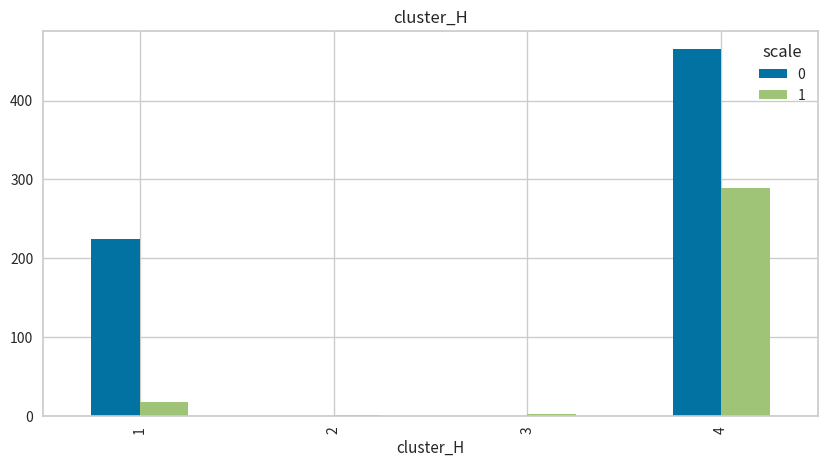

In [1076]:
df_spec_eda = spec_cluster.groupby(["cluster_H",'scale'])['scale'].count().unstack('scale')
df_spec_eda.plot(kind='bar', figsize=(10,5))
plt.title('cluster_H')
plt.show()

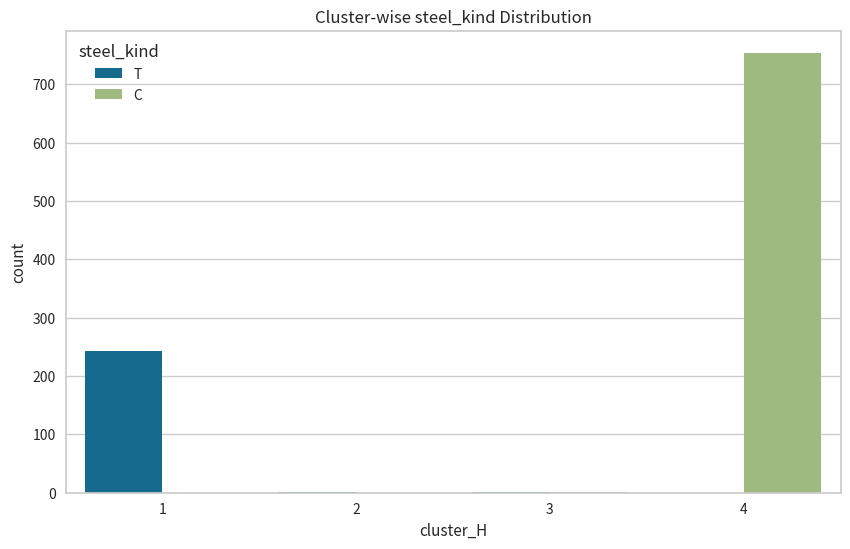

In [1077]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(x='cluster_H', hue='steel_kind', data=spec_cluster)
plt.title("Cluster-wise steel_kind Distribution")
plt.show()

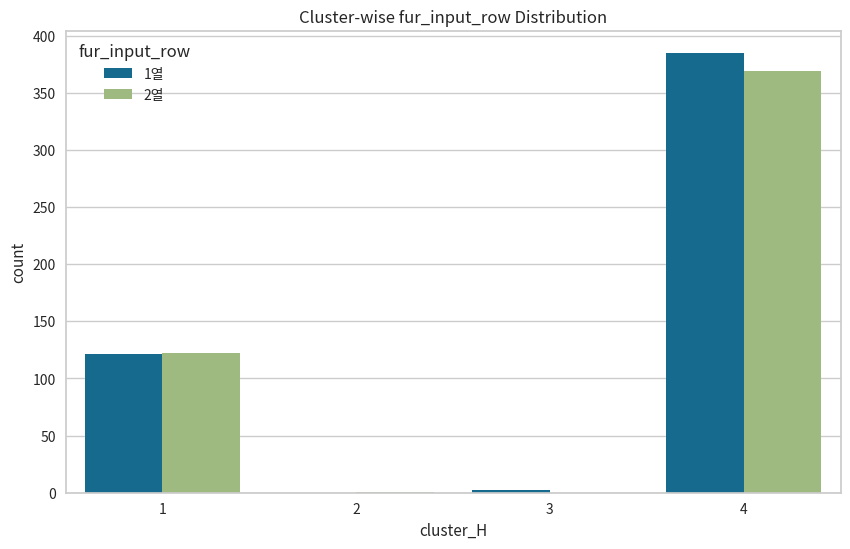

In [1078]:
plt.figure(figsize=(10, 6))
sns.countplot(x='cluster_H', hue='fur_input_row', data=spec_cluster)
plt.title("Cluster-wise fur_input_row Distribution")
plt.show()

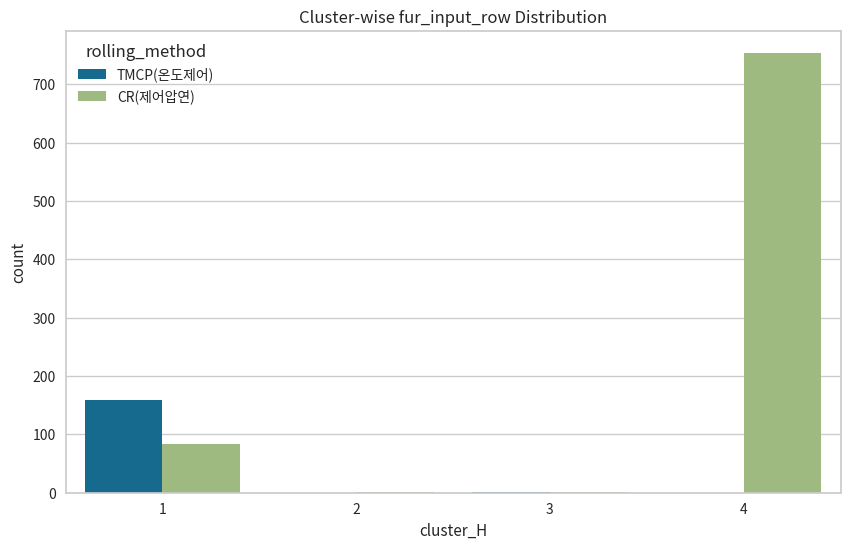

In [1079]:
plt.figure(figsize=(10, 6))
sns.countplot(x='cluster_H', hue='rolling_method', data=spec_cluster)
plt.title("Cluster-wise fur_input_row Distribution")
plt.show()

# cluster_H, scale 카이제곱검정

In [ ]:
cat_cols = ['cluster_H'] 

result = []

for col in cat_cols:
    table = pd.crosstab(spec_cluster[col], df_raw['scale'])
    chi2, p, dof, expected = chi2_contingency(table)
    
    result.append({
        '변수': col,
        'p_value': p.round(4),
        '결과': '○' if p < 0.05 else '×'
    })

result_df = pd.DataFrame(result)
print(result_df)

          변수  p_value 결과
0  cluster_H      0.0  ○


# 데이터 전처리

In [ ]:
spec_cluster['pt_dim']=spec_cluster['pt_width']*spec_cluster['pt_thick']

In [1082]:
spec_cluster.columns

Index(['rolling_date', 'scale', 'spec_country', 'steel_kind', 'pt_thick',
       'pt_width', 'pt_length', 'hsb', 'fur_no', 'fur_input_row',
       'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time',
       'fur_total_time', 'rolling_method', 'rolling_temp', 'descaling_count',
       'work_group', 'pt_dim', 'cluster_H'],
      dtype='object')

In [1083]:
spec_cluster = spec_cluster.drop(['pt_width', 'pt_length','pt_thick','fur_no', 'fur_input_row','fur_heat_time','descaling_count'], axis=1)

In [1084]:
x_raw = spec_cluster.drop('scale', axis = 1, inplace=False)
y_raw = spec_cluster['scale']

In [1085]:
spec_cluster.columns

Index(['rolling_date', 'scale', 'spec_country', 'steel_kind', 'hsb',
       'fur_heat_temp', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time',
       'rolling_method', 'rolling_temp', 'work_group', 'pt_dim', 'cluster_H'],
      dtype='object')

In [1086]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(x_raw, y_raw, test_size=0.3, random_state=1234)

# 2. 전처리 정의
numeric_features = ['fur_heat_temp', 'fur_soak_temp', 'fur_soak_time', 
                    'fur_total_time', 'rolling_temp', 'pt_dim']
categorical_features = ['spec_country', 'steel_kind','rolling_method', 
                        'hsb', 'work_group',]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore',drop='first'), categorical_features)
    ])

preprocessor.set_output(transform="pandas")

# 3. fit & transform
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [1087]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. 전처리 정의
preprocessor = ColumnTransformer(
    transformers=[
        # 스케일링 할 변수들
        ('num', StandardScaler(), numeric_features),
        # 원핫인코딩 할 변수들
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore',drop='first'), categorical_features)
    ], 
    remainder='passthrough',
    verbose_feature_names_out=False 
)

# 2. 판다스 출력 설정
preprocessor.set_output(transform="pandas")

# 3. 실행
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)


# 4. 확인
x_train_processed.head()
x_test_processed.head()

,fur_heat_temp,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,pt_dim,spec_country_독일,spec_country_미국,spec_country_영국,spec_country_일본,spec_country_프랑스,spec_country_한국,steel_kind_T,rolling_method_TMCP(온도제어),hsb_적용,work_group_2조,work_group_3조,work_group_4조,rolling_date,cluster_H
681,-0.013688,-0.269074,0.046181,1.771280,-0.246976,-0.778514,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,08JAN2023:00:56:07,4
990,0.694331,0.760169,-0.488546,-0.450709,1.020416,-0.021776,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,10JAN2023:04:34:10,4
155,0.599929,0.931710,-0.391323,0.711959,1.036063,-0.692471,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,04JAN2023:09:04:36,4
768,0.552727,0.474269,-0.682992,-0.760755,0.441484,-0.657171,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,08JAN2023:16:13:49,4
438,1.166345,1.217611,-0.731604,-1.251659,-0.982377,-0.692471,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,06JAN2023:08:50:40,4


In [1088]:
x_train_processed.drop([ 'spec_country_독일', 'spec_country_미국',
       'spec_country_영국', 'spec_country_일본', 'spec_country_프랑스',
       'spec_country_한국', 'rolling_date'], axis=1,inplace=True)
x_test_processed.drop(['spec_country_독일', 'spec_country_미국',
       'spec_country_영국', 'spec_country_일본', 'spec_country_프랑스',
       'spec_country_한국', 'rolling_date'], axis=1,inplace=True)

In [1089]:
x_train_processed.columns

Index(['fur_heat_temp', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time',
       'rolling_temp', 'pt_dim', 'steel_kind_T', 'rolling_method_TMCP(온도제어)',
       'hsb_적용', 'work_group_2조', 'work_group_3조', 'work_group_4조',
       'cluster_H'],
      dtype='object')

In [1090]:
x_train_processed.columns

Index(['fur_heat_temp', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time',
       'rolling_temp', 'pt_dim', 'steel_kind_T', 'rolling_method_TMCP(온도제어)',
       'hsb_적용', 'work_group_2조', 'work_group_3조', 'work_group_4조',
       'cluster_H'],
      dtype='object')

# Decision Tree

In [1091]:
# 데이터 구성:Series, DataFrame
import pandas as pd
import numpy as np
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# export_graphviz: 나무 구조 생성 및 저장 
from sklearn.tree import export_graphviz
# graphviz : 나무 구조 시각화  (.dot 확장자 파일 불러오기 등)
import graphviz

# 다른 방식(.dot -> .png 형식, 출력화면에 맞는)으로 Tree 출력
from subprocess import call
from IPython.display import Image

# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 분류 Decision Tree
from sklearn.tree import DecisionTreeClassifier
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, classification_report

In [1092]:
tree_uncust = DecisionTreeClassifier(random_state=1234)
tree_uncust.fit(x_train_processed,y_train)

# train 데이터 정확도
print("Accuracy on training set: {:.3f}".format(tree_uncust.score(x_train_processed,y_train)))
# test 데이터 정확도
print("Accuracy on test set: {:.3f}".format(tree_uncust.score(x_test_processed,y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.887


In [1093]:
v_feature_name = x_train_processed.columns

In [1094]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# max_depth: 최대 깊이 변경.
para_depth = [depth for depth in range(1, 10)]

for v_max_depth in para_depth:
    tree = DecisionTreeClassifier(max_depth = v_max_depth, random_state=1234)
    tree.fit(x_train_processed,y_train)
    train_accuracy.append(tree.score(x_train_processed,y_train))
    test_accuracy.append(tree.score(x_test_processed,y_test))

# 데이터 테이블로 저장
df_accuracy_depth = pd.DataFrame()
df_accuracy_depth["Depth"] = para_depth
df_accuracy_depth["TrainAccuracy"] = train_accuracy
df_accuracy_depth["TestAccuracy"] = test_accuracy

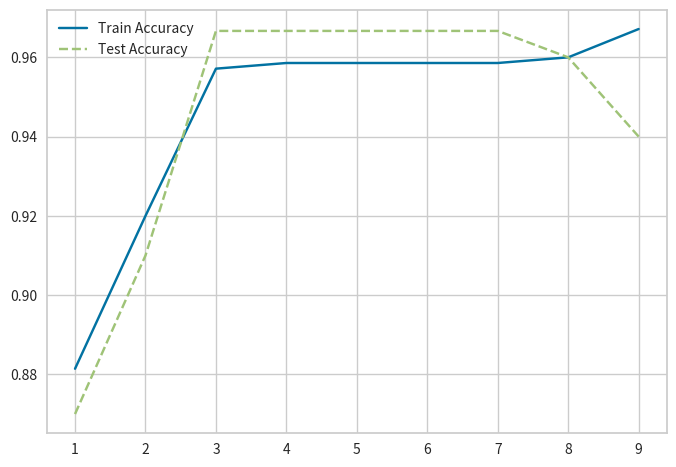

In [1095]:
# 모델 정확도 그래프 확인
plt.plot(para_depth, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_depth, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

In [1096]:
df_accuracy_depth.round(3)

,Depth,TrainAccuracy,TestAccuracy
0,1,0.881,0.870
1,2,0.920,0.910
2,3,0.957,0.967
3,4,0.959,0.967
4,5,0.959,0.967
5,6,0.959,0.967
6,7,0.959,0.967
7,8,0.960,0.960
8,9,0.967,0.940


In [1097]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_split: 분할하기 위한 노드의 최소 샘플 수 
para_split = [n_split * 10 for n_split in range(2, 10)]

for v_min_samples_split in para_split:
    tree = DecisionTreeClassifier(min_samples_split = v_min_samples_split, max_depth=5, random_state=1234)
    tree.fit(x_train_processed,y_train)
    train_accuracy.append(tree.score(x_train_processed,y_train))
    test_accuracy.append(tree.score(x_test_processed,y_test))

# 데이터 테이블로 저장
df_accuracy_split = pd.DataFrame()
df_accuracy_split["MinSamplesSplit"] = para_split
df_accuracy_split["TrainAccuracy"] = train_accuracy
df_accuracy_split["TestAccuracy"] = test_accuracy

In [1098]:
# 모델 정확도 확인
df_accuracy_split.round(3)

,MinSamplesSplit,TrainAccuracy,TestAccuracy
0,20,0.959,0.967
1,30,0.959,0.967
2,40,0.959,0.967
3,50,0.959,0.967
4,60,0.959,0.967
5,70,0.959,0.967
6,80,0.959,0.967
7,90,0.959,0.967


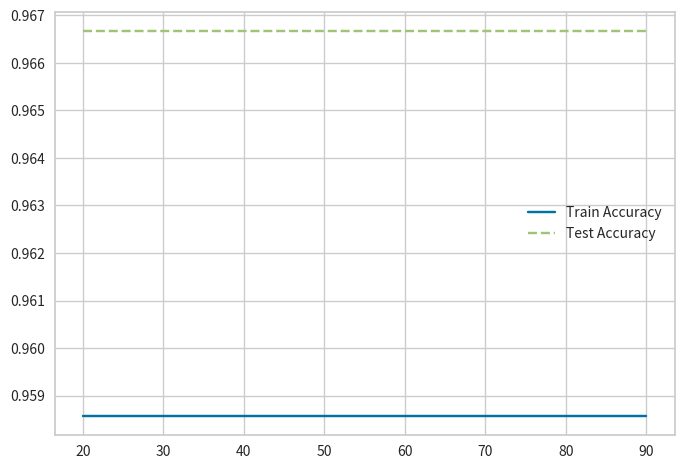

In [1099]:
plt.plot(para_split, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

In [1100]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_leaf: 잎사귀 노드 최소 자료 수. 
para_leaf = [n_leaf * 2 for n_leaf in range(1,13)]

for v_min_samples_leaf in para_leaf:
    tree = DecisionTreeClassifier(min_samples_leaf = v_min_samples_leaf,  \
		max_depth=5, random_state=1234)
    tree.fit(x_train_processed, y_train)
    train_accuracy.append(tree.score(x_train_processed, y_train))
    test_accuracy.append(tree.score(x_test_processed, y_test))

# 데이터 테이블로 저장
df_accuracy_leaf = pd.DataFrame()
df_accuracy_leaf["MinSamplesLeaf"] = para_leaf
df_accuracy_leaf["TrainAccuracy"] = train_accuracy
df_accuracy_leaf["TestAccuracy"] = test_accuracy

In [1101]:
# 모델 정확도 확인
df_accuracy_leaf.round(3)

,MinSamplesLeaf,TrainAccuracy,TestAccuracy
0,2,0.957,0.967
1,4,0.957,0.967
2,6,0.957,0.967
3,8,0.957,0.967
4,10,0.957,0.967
5,12,0.957,0.967
6,14,0.957,0.967
7,16,0.957,0.967
8,18,0.957,0.967
9,20,0.957,0.967


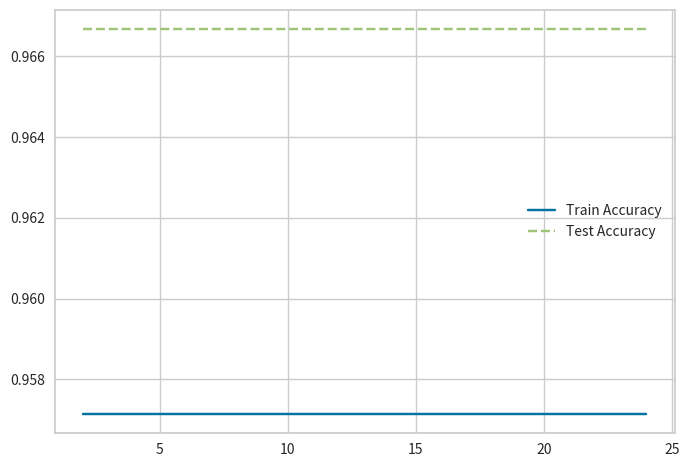

In [1102]:
# 모델 정확도 그래프 확인
plt.plot(para_leaf, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_leaf, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.legend()

In [1103]:
tree_final = DecisionTreeClassifier(max_depth=5, min_samples_leaf=8, random_state=1234)
tree_final.fit(x_train_processed,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1234
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [1104]:
# 분석 모델 리스트
model = ["DecisionTree"]

# 정확도 저장
train_accuracy = []; test_accuracy = []
# auc score 저장
model_auc = []

# Precision, Recall score 저장
model_precision = []; model_recall = []
# f1 score 저장
model_f1_score = []

In [1105]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split

# 분류 Decision Tree
from sklearn.tree import DecisionTreeClassifier
# 분류 Random Forest
from sklearn.ensemble import RandomForestClassifier
# 분류 Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# 분류 NN (MLPClassifier)
from sklearn.neural_network import MLPClassifier

# 모델 성능 평가: Precision, Recall, F1 Score, ROC Curve, AUC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
# xgboost 패키지 불러오기 
from xgboost import XGBClassifier

# 변수 중요도 확인: F1 점수 기준
from xgboost import plot_importance

# Check the Frequency of Variable
from collections import Counter

In [ ]:
# 최종모델
dt_final = DecisionTreeClassifier(max_depth=3, min_samples_leaf=30, min_samples_split=10,
                       random_state=1234)
dt_final.fit(x_train_processed, y_train)

# 정확도
train_accuracy.append(dt_final.score(x_train_processed, y_train))
test_accuracy.append(dt_final.score(x_test_processed, y_test))

# 예측값
y_prob_1 = dt_final.predict_proba(x_test_processed)[:, 1]  # 1 발생 확률
y_pred = dt_final.predict(x_test_processed)  # 1/0 판정

print("Confusion matrix: \n{}".format(confusion_matrix(y_test, y_pred)))
print(classification_report(y_test, y_pred, digits=3))


fpr, tpr, thresholds = roc_curve(y_test, y_prob_1)

Confusion matrix: 
[[205   1]
 [ 27  67]]
              precision    recall  f1-score   support

           0      0.884     0.995     0.936       206
           1      0.985     0.713     0.827        94

    accuracy                          0.907       300
   macro avg      0.934     0.854     0.882       300
weighted avg      0.915     0.907     0.902       300



In [1107]:
model_precision.append(precision_score(y_test, y_pred))
model_recall.append(recall_score(y_test, y_pred))

# f1 score
model_f1_score.append(f1_score(y_test, y_pred))
model_f1_score

[0.8271604938271605]

In [1108]:
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = dt_final.feature_importances_

# df_feature_importance의 테이블을 중요도별로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
4,rolling_temp,0.827
1,fur_soak_temp,0.173
0,fur_heat_temp,0.000
2,fur_soak_time,0.000
3,fur_total_time,0.000
5,pt_dim,0.000
6,steel_kind_T,0.000
7,rolling_method_TMCP(온도제어),0.000
8,hsb_적용,0.000
9,work_group_2조,0.000


Text(0, 0.5, '설명변수')

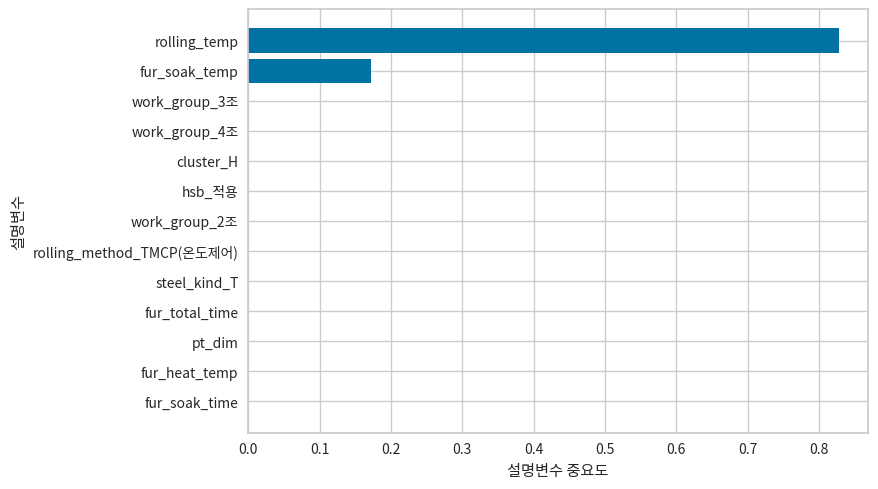

In [ ]:
# 설명변수 중요도 그래프
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

# GradientBoost Classifier

In [1110]:
# 그래디언트 부스팅 모델 생성: GradientBoostingClassifier
gb_uncust = GradientBoostingClassifier(random_state=1234)
gb_uncust.fit(x_train_processed, y_train)

# train 모델 정확도
print("Accuracy on training set: {:.3f}".format(gb_uncust.score (x_train_processed, y_train)))
# test 모델 정확도
print("Accuracy on test set: {:.3f}".format(gb_uncust.score (x_test_processed, y_test)))

Accuracy on training set: 0.969
Accuracy on test set: 0.963


In [1111]:
# 실행옵션 확인
print(gb_uncust.get_params().keys())
print(gb_uncust.get_params().values())

dict_keys(['ccp_alpha', 'criterion', 'init', 'learning_rate', 'loss', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'n_estimators', 'n_iter_no_change', 'random_state', 'subsample', 'tol', 'validation_fraction', 'verbose', 'warm_start'])
dict_values([0.0, 'friedman_mse', None, 0.1, 'log_loss', 3, None, None, 0.0, 1, 2, 0.0, 100, None, 1234, 1.0, 0.0001, 0.1, 0, False])


In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# learning_rate 학습률 변경
para_lr = [lr * 0.1 for lr in range(1, 10)]

for v_learning_rate in para_lr:
    gb = GradientBoostingClassifier(learning_rate = v_learning_rate, random_state = 1234)
    gb.fit(x_train_processed, y_train)
    train_accuracy.append(gb.score(x_train_processed, y_train))
    test_accuracy.append(gb.score(x_test_processed, y_test))

# 데이터 테이블로 저장
df_accuracy_lr = pd.DataFrame()
df_accuracy_lr["LearningRate"] = para_lr
df_accuracy_lr["TrainAccuracy"] = train_accuracy
df_accuracy_lr["TestAccuracy"] = test_accuracy

In [1113]:
# LearningRate별 정확도 
df_accuracy_lr.round(3)

,LearningRate,TrainAccuracy,TestAccuracy
0,0.1,0.969,0.963
1,0.2,0.997,0.957
2,0.3,1.000,0.963
3,0.4,1.000,0.947
4,0.5,1.000,0.950
5,0.6,1.000,0.950
6,0.7,1.000,0.950
7,0.8,1.000,0.950
8,0.9,1.000,0.940


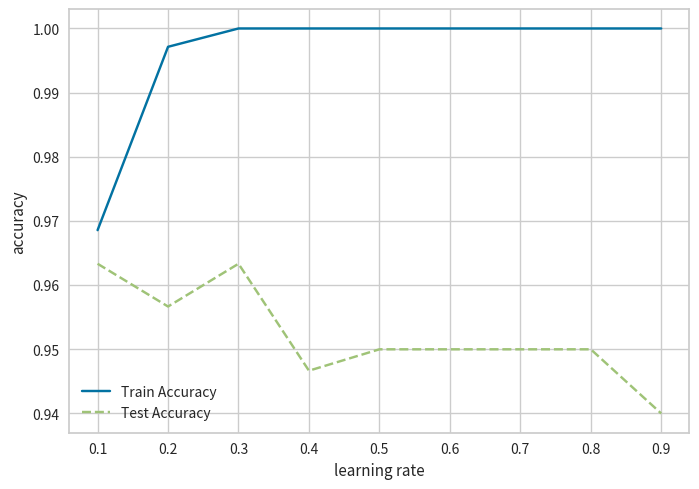

In [1114]:
# LearningRate별 정확도 그래프 확인
plt.plot(para_lr, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_lr, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("learning rate")
plt.legend()

In [1115]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# n_estimatos: 트리 수 변경
para_n_tree = [n_tree * 10 for n_tree in range(1, 16)]

for v_n_estimators in para_n_tree:
    gb = GradientBoostingClassifier(n_estimators = v_n_estimators, learning_rate=0.1, random_state=1234)
    gb.fit(x_train_processed, y_train)
    train_accuracy.append(gb.score(x_train_processed, y_train))
    test_accuracy.append(gb.score(x_test_processed, y_test))

# 데이터 테이블로 저장
df_accuracy_n = pd.DataFrame()
df_accuracy_n["Estimators"] = para_n_tree
df_accuracy_n["TrainAccuracy"] = train_accuracy
df_accuracy_n["TestAccuracy"] = test_accuracy

In [1116]:
# n_estimators별 정확도 
df_accuracy_n.round(3)

,Estimators,TrainAccuracy,TestAccuracy
0,10,0.957,0.967
1,20,0.957,0.967
2,30,0.959,0.967
3,40,0.959,0.967
4,50,0.959,0.967
5,60,0.960,0.967
6,70,0.964,0.967
7,80,0.966,0.967
8,90,0.969,0.963
9,100,0.969,0.963


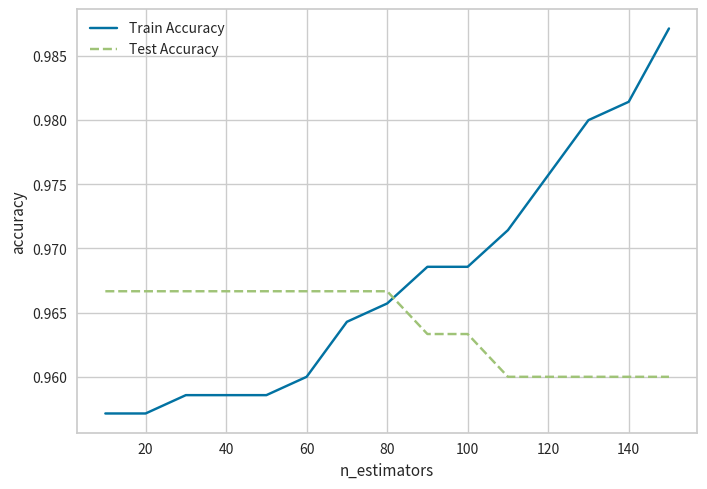

In [1117]:
# 정확도를 그래프 확인
plt.plot(para_n_tree, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_n_tree, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("n_estimators")
plt.legend()

In [1118]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# max_depth: 최대 깊이 변경. 1~10
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    gb = GradientBoostingClassifier(max_depth = v_max_depth,
                            n_estimators=80, learning_rate=0.1, random_state=1234)
    gb.fit(x_train_processed, y_train)
    train_accuracy.append(gb.score(x_train_processed, y_train))
    test_accuracy.append(gb.score(x_test_processed, y_test))
    
# 데이터 테이블로 저장
df_accuracy_depth = pd.DataFrame()
df_accuracy_depth["Depth"] = para_depth
df_accuracy_depth["TrainAccuracy"] = train_accuracy
df_accuracy_depth["TestAccuracy"] = test_accuracy

In [1119]:
# max_depth별 정확도
df_accuracy_depth.round(3)

,Depth,TrainAccuracy,TestAccuracy
0,1,0.957,0.967
1,2,0.959,0.967
2,3,0.966,0.967
3,4,0.981,0.957
4,5,0.997,0.960
5,6,1.000,0.953
6,7,1.000,0.957
7,8,1.000,0.940
8,9,1.000,0.947
9,10,1.000,0.950


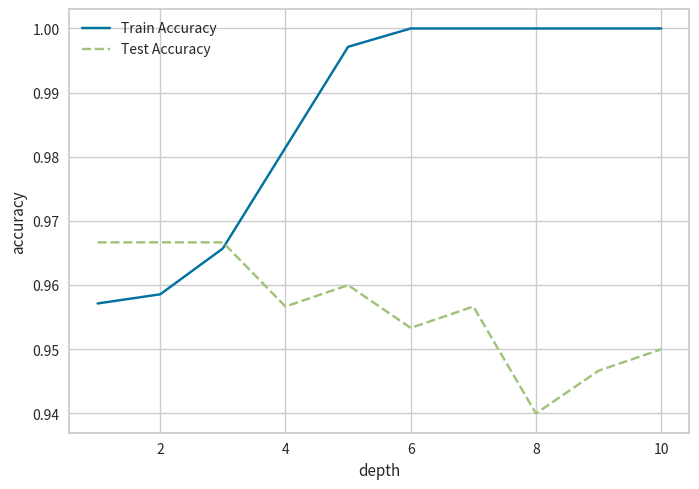

In [1120]:
# 정확도를 그래프 확인
plt.plot(para_depth, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_depth, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("depth")
plt.legend()

In [1121]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_split: 분할하기 위한 노드의 최소 샘플 수. 20~100
para_split = [n_split * 10 for n_split in range(2, 11)]

for v_min_samples_split in para_split:
    gb = GradientBoostingClassifier(min_samples_split = v_min_samples_split,
                                    max_depth=3, n_estimators=80, learning_rate=0.1, random_state=1234)
    gb.fit(x_train_processed, y_train)
    train_accuracy.append(gb.score(x_train_processed, y_train))
    test_accuracy.append(gb.score(x_test_processed, y_test))

# 데이터 테이블로 저장
df_accuracy_split = pd.DataFrame()
df_accuracy_split["MinSamplesSplit"] = para_split
df_accuracy_split["TrainAccuracy"] = train_accuracy
df_accuracy_split["TestAccuracy"] = test_accuracy

In [1122]:
# min_samples_leaf별 정확도 
df_accuracy_split.round(3)

,MinSamplesSplit,TrainAccuracy,TestAccuracy
0,20,0.961,0.967
1,30,0.963,0.963
2,40,0.963,0.967
3,50,0.960,0.967
4,60,0.960,0.967
5,70,0.961,0.967
6,80,0.963,0.967
7,90,0.963,0.967
8,100,0.961,0.967


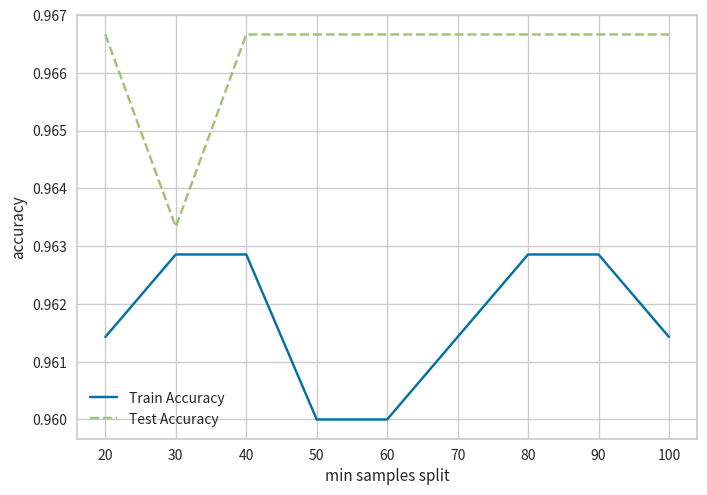

In [1123]:
# 정확도를 그래프 확인
plt.plot(para_split, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("min samples split")
plt.legend()

In [1124]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_leaf: 잎사귀 노드 최소 자료 수. 5~50
para_leaf = [n_leaf * 5 for n_leaf in range(1, 11)]

for v_min_samples_leaf in para_leaf:
    gb = GradientBoostingClassifier(min_samples_leaf = v_min_samples_leaf,
                                    max_depth=3, n_estimators=80, learning_rate=0.1, random_state=1234)
    gb.fit(x_train_processed, y_train)
    train_accuracy.append(gb.score(x_train_processed, y_train))
    test_accuracy.append(gb.score(x_test_processed, y_test))

# 데이터 테이블로 저장
df_accuracy_leaf = pd.DataFrame()
df_accuracy_leaf["MinSamplesLeaf"] = para_leaf
df_accuracy_leaf["TrainAccuracy"] = train_accuracy
df_accuracy_leaf["TestAccuracy"] = test_accuracy

In [1125]:
# min_samples_leaf별 정확도 
df_accuracy_leaf.round(3)

,MinSamplesLeaf,TrainAccuracy,TestAccuracy
0,5,0.963,0.960
1,10,0.961,0.963
2,15,0.961,0.963
3,20,0.959,0.967
4,25,0.959,0.967
5,30,0.919,0.907
6,35,0.917,0.897
7,40,0.914,0.893
8,45,0.916,0.897
9,50,0.914,0.887


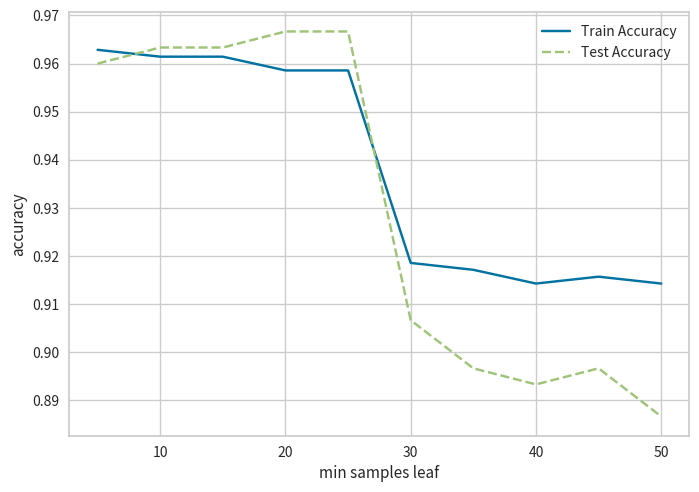

In [1126]:
# 정확도를 그래프 확인
plt.plot(para_leaf, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_leaf, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("min samples leaf")
plt.legend()

In [1127]:
# 최종 모델
gb_final = GradientBoostingClassifier(min_samples_leaf=10, max_depth=8, n_estimators=100, learning_rate=0.2, random_state=1234)
gb_final.fit(x_train_processed, y_train)
# 예측
y_pred = gb_final.predict(x_test_processed)

# train 모델 정확도
print("Train Accuracy: {:.3f}".format(gb_final.score(x_train_processed, y_train)))
# test 모델 정확도
print("Test Accuracy: {:.3f}\n".format(gb_final.score(x_test_processed, y_test)))
# confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(y_test, y_pred)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(y_test, y_pred, digits=3))

Train Accuracy: 1.000
Test Accuracy: 0.950

Test Confusion matrix: 
[[200   6]
 [  9  85]]
              precision    recall  f1-score   support

           0      0.957     0.971     0.964       206
           1      0.934     0.904     0.919        94

    accuracy                          0.950       300
   macro avg      0.946     0.938     0.941       300
weighted avg      0.950     0.950     0.950       300



In [1128]:
# 변수명
v_feature_name = x_train_processed.columns
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance ["Feature"] = v_feature_name
df_importance ["Importance"] = gb_final.feature_importances_
# df_feature_importance의 테이블을 중요도별로 정렬
df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
4,rolling_temp,0.587
1,fur_soak_temp,0.161
8,hsb_적용,0.158
3,fur_total_time,0.032
0,fur_heat_temp,0.026
2,fur_soak_time,0.019
5,pt_dim,0.016
7,rolling_method_TMCP(온도제어),0.001
9,work_group_2조,0.000
10,work_group_3조,0.000


Text(0, 0.5, '설명변수')

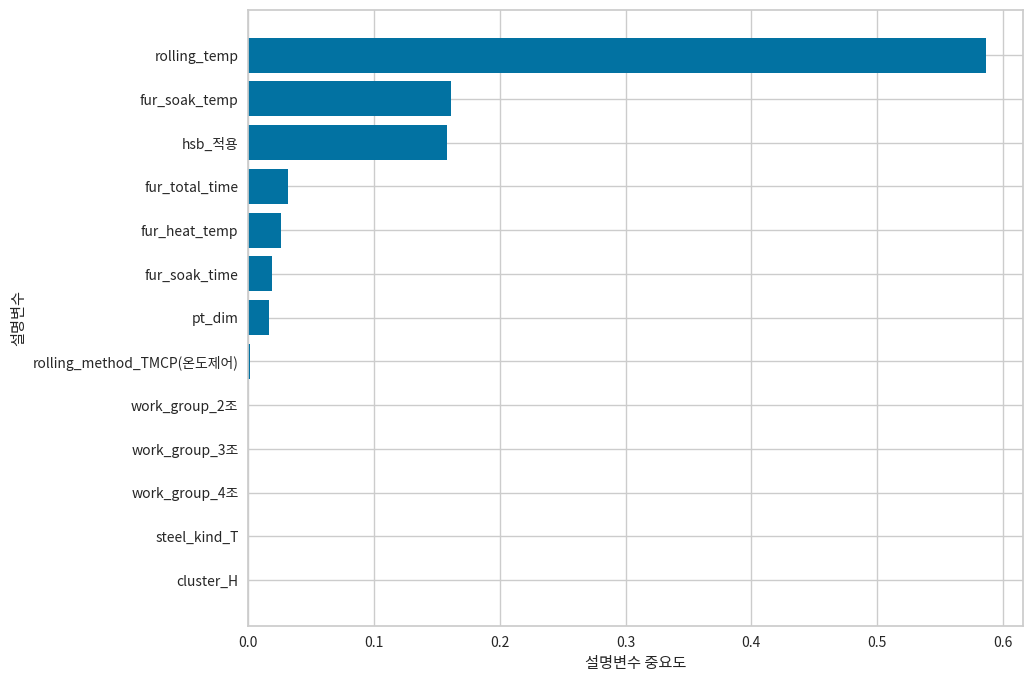

In [1129]:
# 설명변수 중요도 그래프
# 중요도가 높은 변수를 상위에 그림 
fig, ax = plt.subplots(figsize=(10, 8))

df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance ))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

# Random Forest 분류

In [1130]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, classification_report


In [1131]:
# 파라미터 범위 설정
para_n_tree = [50, 100] # 나무의 개수 추가
para_depth = [depth for depth in range(1, 11)] # 1~10 깊이
para_split = [10, 20, 30] # 노드 분할 최소 샘플
para_leaf = [5, 10] # 잎사귀 최소 샘플

estimator = RandomForestClassifier(n_estimators=100,random_state=1234)
param_grid = {"max_depth": para_depth, "min_samples_leaf": para_leaf}
# 정확도가 높은 최적 parameter 찾기
grid_rf = GridSearchCV(estimator, param_grid, scoring="accuracy", n_jobs = 1)
grid_rf.fit(x_train_processed, y_train)
print("best estimator model: \n{}".format(grid_rf.best_estimator_))
print("\nbest parameter: \n{}".format(grid_rf.best_params_))
print("\nbest score: \n{}".format(grid_rf.best_score_.round(3)))

best estimator model: 
RandomForestClassifier(max_depth=5, min_samples_leaf=5, random_state=1234)

best parameter: 
{'max_depth': 5, 'min_samples_leaf': 5}

best score: 
0.946


In [1132]:
# 최종 모델
rf_final = RandomForestClassifier(min_samples_leaf=5, max_depth=5, n_estimators=100,                                  
                                  random_state=1234)
rf_final.fit(x_train_processed, y_train)
# 평가
y_pred_train = rf_final.predict(x_train_processed)
y_pred_test = rf_final.predict(x_test_processed)
# train 데이터 정확도
print("Accuracy on training set: {:.3f}".format(rf_final.score(x_train_processed, y_train)))
# test 데이터 정확도
print("Accuracy on test set: {:.3f}\n".format(rf_final.score(x_test_processed, y_test)))
# confusion matrix
print("Confusion matrix: \n{}".format(confusion_matrix(y_test, y_pred_test)))
# 목표변수의 빈도 불균형 : f1 score로 모델 평가 
print(classification_report(y_test, y_pred_test, digits=3))


Accuracy on training set: 0.951
Accuracy on test set: 0.957

Confusion matrix: 
[[206   0]
 [ 13  81]]
              precision    recall  f1-score   support

           0      0.941     1.000     0.969       206
           1      1.000     0.862     0.926        94

    accuracy                          0.957       300
   macro avg      0.970     0.931     0.948       300
weighted avg      0.959     0.957     0.956       300



In [1133]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
# 예측값 및 확률값 준비
y_pred_train = rf_final.predict(x_train_processed)
y_pred_test = rf_final.predict(x_test_processed)
y_proba_test = rf_final.predict_proba(x_test_processed)[:, 1]

# 수치 출력
print(f"Train Accuracy : {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Test Accuracy  : {accuracy_score(y_test, y_pred_test):.3f}")
print(f"AUC (Test)     : {roc_auc_score(y_test, y_proba_test):.3f}")
print(f"Precision      : {precision_score(y_test, y_pred_test):.3f}")
print(f"Recall         : {recall_score(y_test, y_pred_test):.3f}")
print(f"F1-Score       : {f1_score(y_test, y_pred_test):.3f}")

Train Accuracy : 0.951
Test Accuracy  : 0.957
AUC (Test)     : 0.964
Precision      : 1.000
Recall         : 0.862
F1-Score       : 0.926


In [1134]:
v_feature_names = x_train_processed.columns
df_importance = pd.DataFrame()
df_importance ["Feature"] = v_feature_names
df_importance ["Importance"] = rf_final.feature_importances_
df_importance .sort_values("Importance", ascending=False, inplace = True)
df_importance .round(3)


,Feature,Importance
4,rolling_temp,0.488
1,fur_soak_temp,0.146
8,hsb_적용,0.093
0,fur_heat_temp,0.074
5,pt_dim,0.059
12,cluster_H,0.038
3,fur_total_time,0.034
2,fur_soak_time,0.028
6,steel_kind_T,0.024
11,work_group_4조,0.006


Text(0, 0.5, '설명변수')

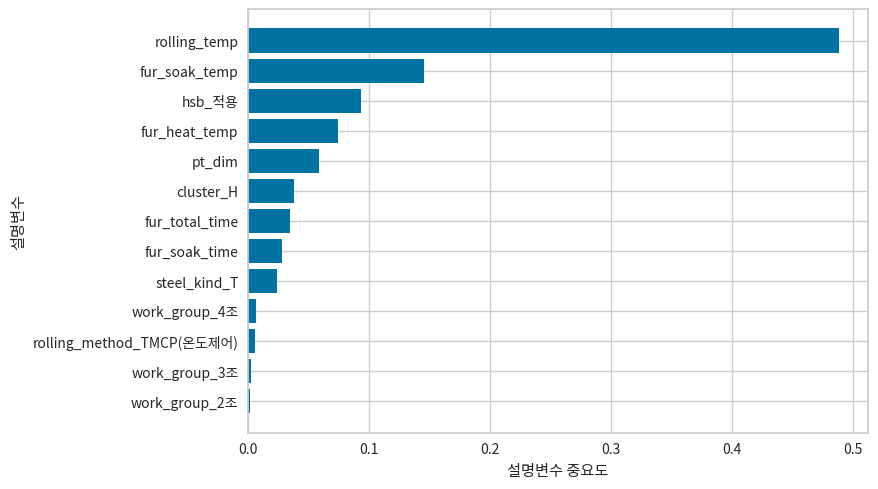

In [1135]:

df_importance .sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance ))
plt.barh(y = coordinates, width = df_importance ["Importance"])
plt.yticks(coordinates, df_importance ["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

# XGBoost 분류

In [1136]:
# xgboost 패키지 불러오기 
from xgboost import XGBClassifier
# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
# 변수 중요도 확인: F1 점수 기준
from xgboost import plot_importance


In [1137]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(random_state=1234, use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [50, 100, 150],          
    'learning_rate': [0.01, 0.1, 0.3],  
    'max_depth': [3, 5, 7],              
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,                 
    scoring='accuracy',  # 'accuracy', 'f1_macro', 'roc_auc' 중 선택
    n_jobs=-1            
)

grid_xgb.fit(x_train_processed, y_train)

print("최적 파라미터:", grid_xgb.best_params_)
print("최고 평균 Accuracy (Train):", grid_xgb.best_score_)

best_model = grid_xgb.best_estimator_
xgb_y_pred = best_model.predict(x_test_processed)
print("최종 Test Accuracy:", accuracy_score(y_test, xgb_y_pred))
print("\n상세 리포트:\n", classification_report(y_test, xgb_y_pred))

최적 파라미터: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
최고 평균 Accuracy (Train): 0.955730408520108
최종 Test Accuracy: 0.9666666666666667

상세 리포트:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       206
           1       1.00      0.89      0.94        94

    accuracy                           0.97       300
   macro avg       0.98      0.95      0.96       300
weighted avg       0.97      0.97      0.97       300



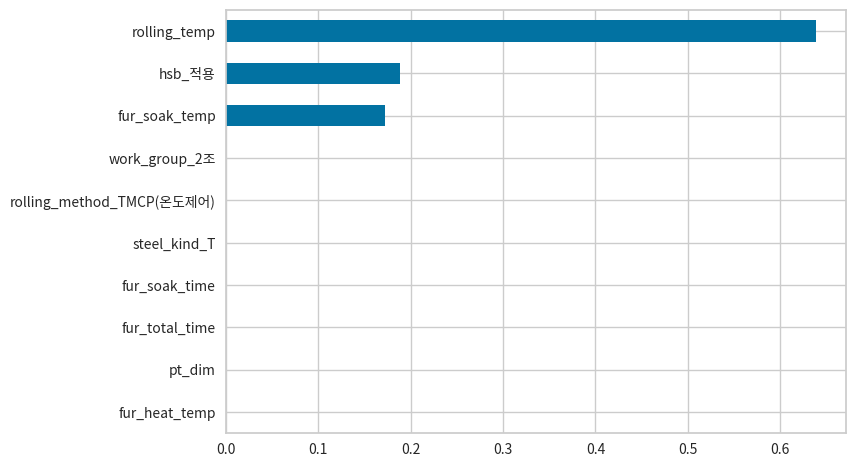

In [1138]:
# 중요도 확인
feature_imp = pd.Series(best_model.feature_importances_, index=x_train_processed.columns)
feature_imp.nlargest(10).sort_values(ascending=True).plot(kind='barh')
plt.show()

# Logistic regression 분류

In [1139]:
x_train_processed.columns

Index(['fur_heat_temp', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time',
       'rolling_temp', 'pt_dim', 'steel_kind_T', 'rolling_method_TMCP(온도제어)',
       'hsb_적용', 'work_group_2조', 'work_group_3조', 'work_group_4조',
       'cluster_H'],
      dtype='object')

In [1140]:
x_train_processed.nunique()

fur_heat_temp                 98
fur_soak_temp                 70
fur_soak_time                 97
fur_total_time               158
rolling_temp                 214
pt_dim                       188
steel_kind_T                   2
rolling_method_TMCP(온도제어)      2
hsb_적용                         2
work_group_2조                  2
work_group_3조                  2
work_group_4조                  2
cluster_H                      4
dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. 모델 생성
sklearn_log_model = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0)

# 2. 모델 학습
sklearn_log_model.fit(x_train_processed, y_train)

# 3. 예측값 얻기
y_pred = sklearn_log_model.predict(x_test_processed)
y_prob = sklearn_log_model.predict_proba(x_test_processed)[:, 1] # 확률값

# 4. 결과 출력
print("### Confusion Matrix ###")
print(confusion_matrix(y_test, y_pred))
print("\n### Classification Report ###")
print(classification_report(y_test, y_pred))

### Confusion Matrix ###
[[190  16]
 [ 19  75]]

### Classification Report ###
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       206
           1       0.82      0.80      0.81        94

    accuracy                           0.88       300
   macro avg       0.87      0.86      0.86       300
weighted avg       0.88      0.88      0.88       300



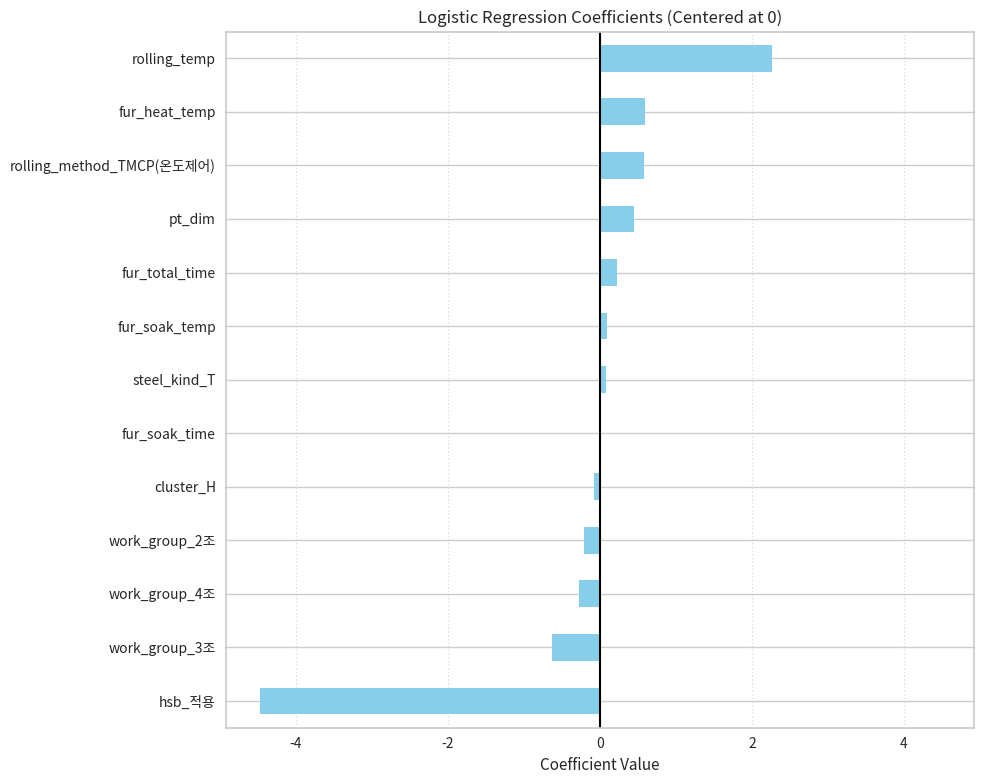

In [1142]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비 (정렬 포함)
df_logistic_coef = pd.DataFrame({
    "Coef": sklearn_log_model.coef_[0]
}, index=x_train_processed.columns).sort_values(by='Coef', ascending=True)

# 2. 시각화
plt.figure(figsize=(10, 8))
ax = df_logistic_coef['Coef'].plot(kind='barh', color='skyblue')

max_val = np.abs(df_logistic_coef['Coef']).max()
plt.xlim(-max_val * 1.1, max_val * 1.1) 

plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
plt.title("Logistic Regression Coefficients (Centered at 0)")
plt.xlabel("Coefficient Value")
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# 모델별 평가지표 확인

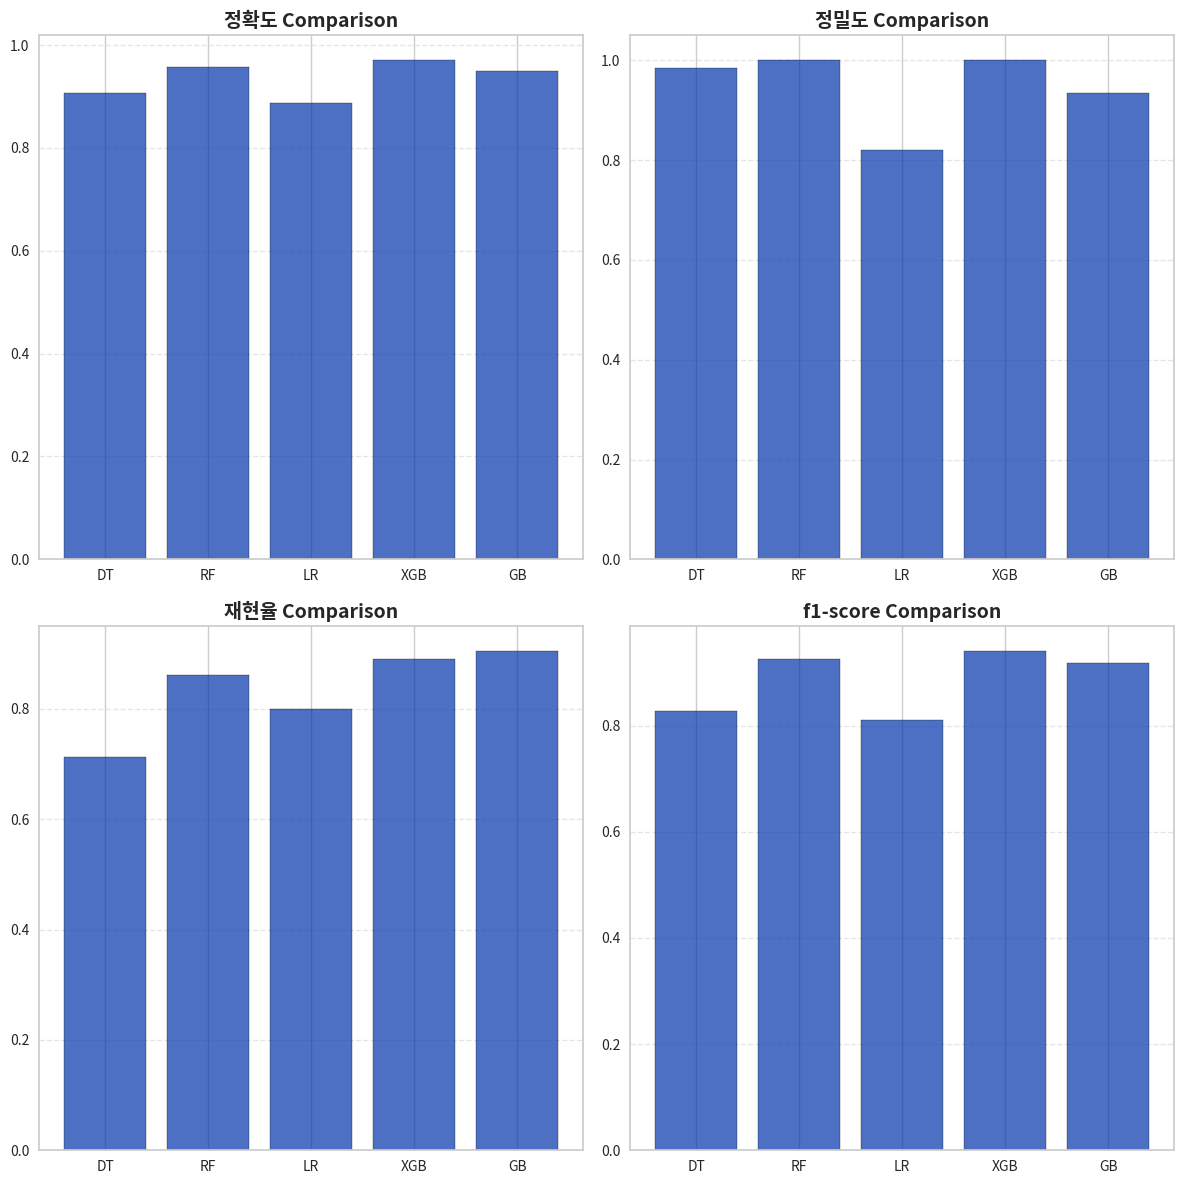

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 정리 (입력값 기반)
data = {
    'Model': ['DT',  'RF', 'LR', 'XGB', 'GB'],
    '정확도': [0.907,  0.957, 0.8867, 0.97, 0.95],
    '정밀도': [0.985,  1, 0.82, 1, 0.934],
    '재현율': [0.713,  0.862, 0.80, 0.89, 0.904],
    'f1-score': [0.827,  0.926, 0.81, 0.94, 0.919]
}

df = pd.DataFrame(data)

# 2. 시각화 (3행 2열 격자)
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
metrics = ['정확도', '정밀도', '재현율', 'f1-score']

for i, metric in enumerate(metrics):
    row, col = i // 2, i % 2

    color = '#0134ab'
    ax[row, col].bar(df['Model'], df[metric], color=color, edgecolor='black', alpha=0.7)
    ax[row, col].set_title(f"{metric} Comparison", fontsize=14, fontweight='bold')
    ax[row, col].grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

# temp_gap 구간별 불량개수

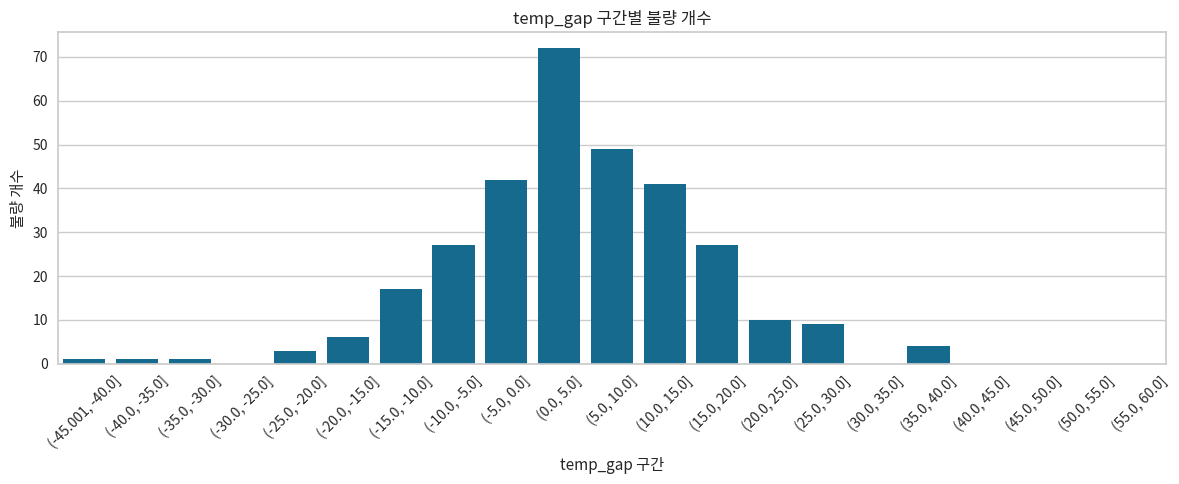

In [1144]:
df_raw_time = df_raw[['rolling_date', 'scale', 'fur_no', 'fur_input_row',
                      'fur_heat_temp', 'fur_heat_time',
                      'fur_soak_temp', 'fur_soak_time', 'fur_total_time']]

df_raw_time['rolling_date'] = pd.to_datetime(df_raw['rolling_date'], format='%d%b%Y:%H:%M:%S')
df_raw_fur = df_raw[["scale","fur_no","fur_input_row","fur_heat_temp","fur_heat_time","fur_soak_temp","fur_soak_time","fur_total_time"]]
df_raw_fur['temp_gap'] = df_raw_fur['fur_heat_temp'] - df_raw_fur['fur_soak_temp']

bins = np.arange(df_raw_fur['temp_gap'].min(), df_raw_fur['temp_gap'].max() + 5, 5)
df_raw_fur['temp_gap_bin'] = pd.cut(df_raw_fur['temp_gap'], bins=bins, include_lowest=True)

temp_gap_count = df_raw_fur.groupby('temp_gap_bin', as_index=False)['scale'].sum()

plt.figure(figsize=(12, 5))
sns.barplot(data=temp_gap_count, x='temp_gap_bin', y='scale')
plt.xticks(rotation=45)
plt.title('temp_gap 구간별 불량 개수')
plt.xlabel('temp_gap 구간')
plt.ylabel('불량 개수')
plt.tight_layout()
plt.show()